In [1]:
import MotifCompendium
import numpy as np
annotation_col="chipdb"

# mc = MotifCompendium.load("tutorials/chrombpnet_outputs/motif_compendium_annotated_new.mc", safe=True)
# mc_sub = mc[mc[f'{annotation_col}_score1'] > 0]
import MotifCompendium
mc = MotifCompendium.load("motif_compendium_chip_selex_annotated.mc", safe=True)
mcf = mc[mc["flag_remove"]==False]
mct = mcf[(mcf["selex_score0"]>0.6) & (mcf["chipdb_score1"]>0.5)]

# #reference_meme = '/mnt/lab_data2/anusri/MotifCompendium/tutorials/chrombpnet_outputs/meme_invitro_avg.meme.txt'
# #reference_meme = '/mnt/lab_data2/anusri/MotifCompendium/tutorials/chrombpnet_outputs/meme_invitro_avg.meme.txt'
# reference_meme = 'pipeline/data/MotifCompendium-Database-Human.meme.txt'

#mcref = MotifCompendium.build_from_pfm({"": reference_meme})

mc_chip = MotifCompendium.load("/oak/stanford/groups/akundaje/cmyun/motifcompendium/tfatlas/encode_qc/pipeline/counts/pipeline_counts_0.88-rec-force0.92-v2/motifcompendium_cluster_labeled.mc", safe=True)
mc_chip["label"]=mc_chip["target"]+"add"+mc_chip["family"]+'add'+mc_chip["MotifCompendium-Database-Human.meme_name0"]+'add'+mc_chip["reference_name0"]
df = mc_chip.metadata[['name', 'label']]
newmct = mct.metadata.merge(df, right_on="name", left_on="chipdb_name1")
newmct["chipdb_name1"] = newmct["label"]
mct.metadata = newmct

In [2]:
mc_sub=mct
mcref=mc_chip
mc_sub.metadata.shape

(66, 27)

In [3]:
#mc[f'{annotation_col}_score1'].max()

In [4]:
#sum(mc_sub[f'{annotation_col}_score1'] > 0.6)

In [5]:
mc_sub.metadata.shape

(66, 27)

In [6]:
#mc[mc[f'{annotation_col}_score1'] > 0]
#mcref
#mc_sub[]

In [7]:
def find_max_similarity_position(debug, matrix_full, matrix_ref, prev_best=None):
    # Extract the number of rows in the submatrix (9) and the larger matrix (30)
    num_rows_submatrix, num_columns = matrix_ref.shape
    num_rows_matrix, _ = matrix_full.shape

    
    
    # Stack submatrices from the 30x4 matrix into a 3D array
    submatrices = np.lib.stride_tricks.sliding_window_view(matrix_full, num_rows_submatrix, axis=0)

    #print(submatrices.shape)
    submatrices_reshaped = submatrices.swapaxes(1, 2)

    # Compute the dot product for each submatrix and the 9x4 matrix
    dot_products = np.sum(submatrices_reshaped * matrix_ref, axis=(1, 2))
    
    # Find the position with the maximum similarity
    best_position1 = np.argmax(dot_products)
    max_similarity1 = dot_products[best_position1]

    # if debug:
    #     print(f'The position with the maximum similarity is: {best_position1}')
    #     print(f'The maximum similarity is: {max_similarity1}')


    # reverse complement

    matrix_ref = matrix_ref[::-1, ::-1]
    # Compute the dot product for each submatrix and the 9x4 matrix
    dot_products = np.sum(submatrices_reshaped * matrix_ref, axis=(1, 2))
    
    # Find the position with the maximum similarity
    best_position2 = np.argmax(dot_products)
    max_similarity2 = dot_products[best_position2]

    # if debug:
    #     print(f'The position with the maximum similarity is: {best_position2}')
    #     print(f'The maximum similarity is: {max_similarity2}')

    if max_similarity1>max_similarity2:
        best_position=best_position1  
    else:
        best_position=best_position2

    if prev_best is not None:
        if (best_position>prev_best[0]) & (best_position<prev_best[1]):
            best_position = prev_best[1]
    return my_motifs[best_position:best_position+num_rows_submatrix], best_position

In [12]:
def find_max_similarity_position_new(debug, matrix_full, matrix_ref, prev_best=None):

    matrix_full = np.abs(matrix_full)
    matrix_ref = np.abs(matrix_ref)
    
    num_rows_ref, num_columns = matrix_ref.shape
    num_rows_full, _ = matrix_full.shape
    
    best_similarity = -np.inf
    best_position = 0
    best_end_position = 0
    best_orientation = "forward"
    
    def calculate_all_overlaps(matrix_full, matrix_ref, orientation="forward"):
        overlaps = []
        
        # Case 1: matrix_ref starts before matrix_full (partial overlap at beginning)
        for i in range(1, num_rows_ref):
            ref_part = matrix_ref[i:, :]  # Take bottom part of ref
            full_part = matrix_full[:num_rows_ref-i, :]  # Take top part of full
            similarity = np.sum(ref_part * full_part)
            start_pos = -(num_rows_ref - i)  # Negative position (before start)
            end_pos = i
            overlaps.append((similarity, start_pos, end_pos, orientation))
        
        # Case 2: Full overlap (matrix_ref completely within matrix_full)
        for i in range(num_rows_full - num_rows_ref + 1):
            full_part = matrix_full[i:i+num_rows_ref, :]
            similarity = np.sum(matrix_ref * full_part)
            start_pos = i
            end_pos = i + num_rows_ref
            overlaps.append((similarity, start_pos, end_pos, orientation))
        
        # Case 3: matrix_ref extends beyond matrix_full (partial overlap at end)
        for i in range(1, num_rows_ref):
            if num_rows_full - i <= 0:
                break
            ref_part = matrix_ref[:i, :]  # Take top part of ref
            full_part = matrix_full[num_rows_full-i:, :]  # Take bottom part of full
            similarity = np.sum(ref_part * full_part)
            start_pos = num_rows_full - i
            end_pos = num_rows_full + (num_rows_ref - i)
            overlaps.append((similarity, start_pos, end_pos, orientation))
        
        return overlaps
    
    # Forward orientation
    forward_overlaps = calculate_all_overlaps(matrix_full, matrix_ref, "forward")
    
    # Reverse complement orientation
    matrix_ref_rc = matrix_ref[::-1, ::-1]
    reverse_overlaps = calculate_all_overlaps(matrix_full, matrix_ref_rc, "reverse")
    
    # Find best overlap from all possibilities
    all_overlaps = forward_overlaps + reverse_overlaps
    
    for similarity, start_pos, end_pos, orientation in all_overlaps:
        if similarity > best_similarity:
            best_similarity = similarity
            best_position = start_pos
            best_end_position = end_pos
            best_orientation = orientation
    
    # if debug:
    #     print(f'The position with the maximum similarity is: {best_position} to {best_end_position}')
    #     print(f'The maximum similarity is: {best_similarity}')
    #     print(f'Best orientation: {best_orientation}')
    
    # Apply prev_best constraint if provided
    if prev_best is not None:
        if best_position > prev_best[0] and best_position < prev_best[1]:
            best_position = prev_best[1]
            best_end_position = best_position + num_rows_ref
    
    # Extract the corresponding region from matrix_full
    # Handle edge cases where the best position extends beyond matrix boundaries
    extract_start = max(0, best_position)
    extract_end = min(num_rows_full, best_end_position)
    
    if extract_start < extract_end:
        extracted_region = matrix_full[extract_start:extract_end, :]
    else:
        # If no valid region can be extracted, return the original ref matrix
        extracted_region = matrix_ref
    
    return extracted_region, best_position, best_end_position

(1, 30, 8)


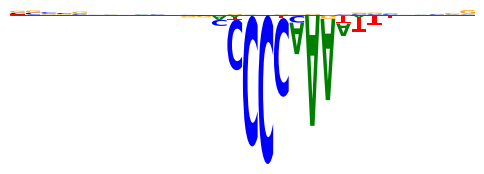

CCCCA
AAATTTA


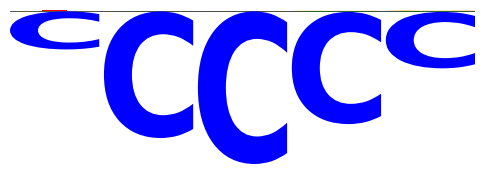

CTCF,JUND


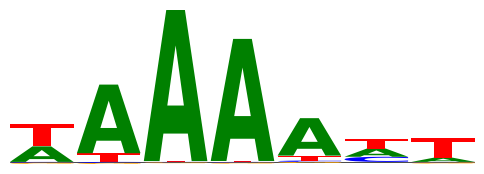

CTCF,JUN
(1, 30, 8)


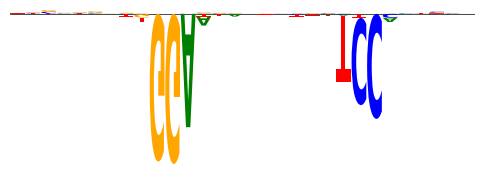

GGA
TCC


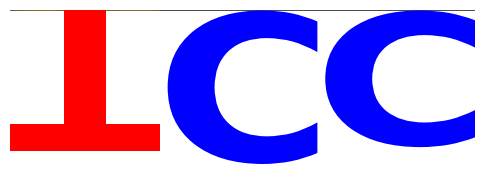

MEF2B


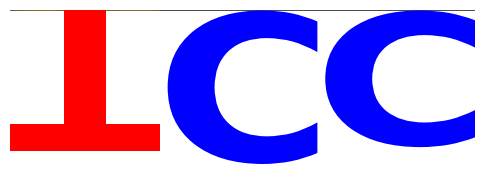

MEF2B
(1, 30, 8)


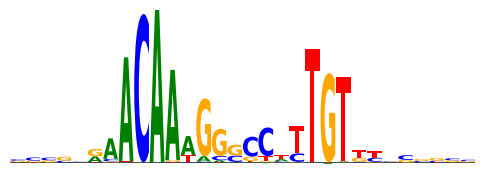

AACAAAGG
CCTTTGTT


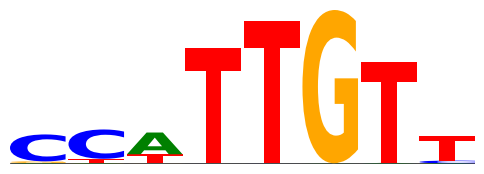

SOX13,SOX5,SOX6


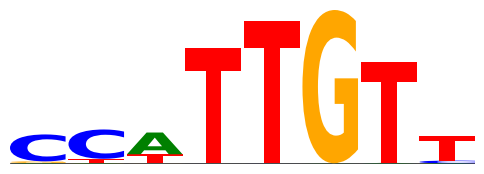

SOX
(1, 30, 8)


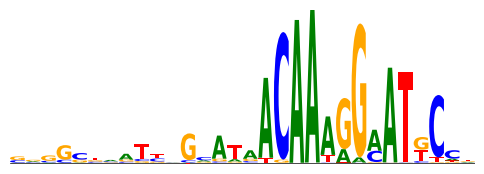

AACAAAGG
AATGCCT


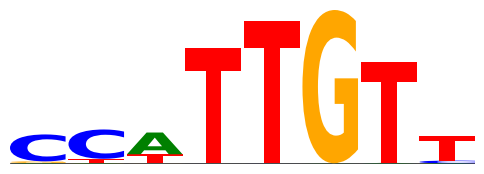

SOX13,SOX5,SOX6


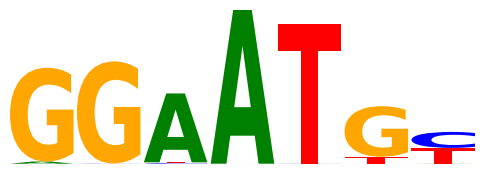

SOX
(1, 30, 8)


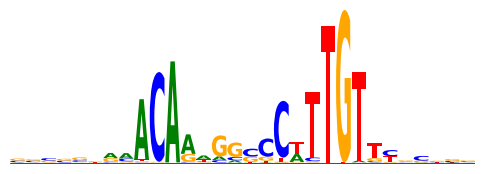

CCTTTGTT
AACAAAGG


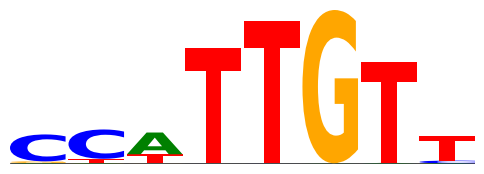

SOX13,SOX5,SOX6


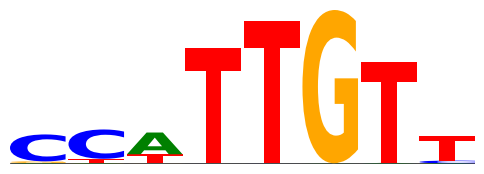

SOX
(1, 30, 8)


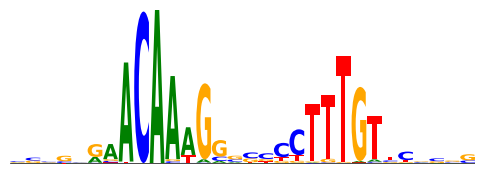

AACAAAGG
CCTTTGTT


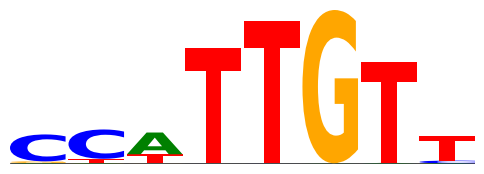

SOX13,SOX5,SOX6


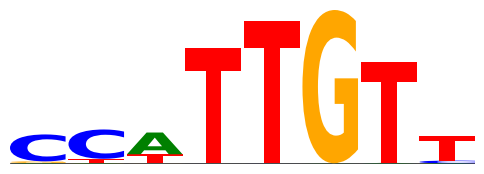

SOX
(1, 30, 8)


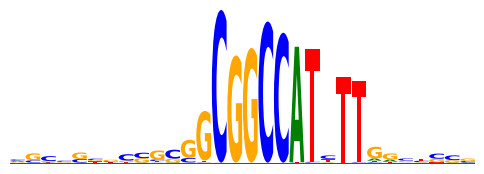

GCGGCCATCTT
GCGAAA


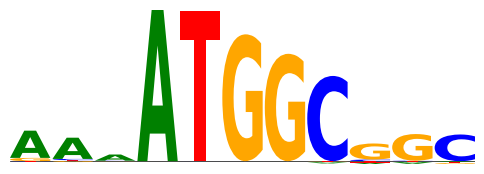

E2F5,EGR1,MXD1,NR2C1,RREB1,YY1,YY2,ZHX1,ZHX2,ZNF197,ZNF395,ZNF507,ZNF583,ZNF639,ZNF644,ZNF766


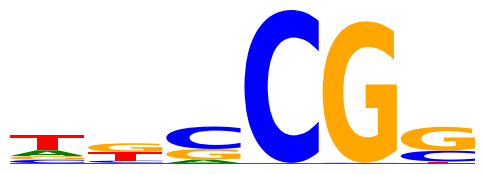

E2F,EGR,MAX,NR2C,RREB,YY,ZHX,ZNF
(1, 30, 8)


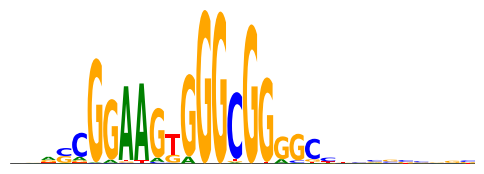

GGGCGGGG
CCGGAAG


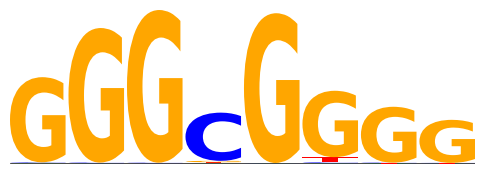

ARNT2,BCL3,BHLHE40,CEBPB,CLOCK,CREB1,ELF1,ETV6,FOS,FOXK1,GMEB1,HIVEP1,HOXA5,JUN,JUND,KLF1,KLF10,KLF12,KLF13,KLF16,KLF17,KLF4,KLF6,KLF7,KLF8,KLF9,MAFK,MAX,MAZ,MEIS2,MNT,MXI1,MYC,NRF1,PKNOX1,POU2F1,POU2F2,RREB1,RUNX3,SP1,SP2,SP3,SP4,SP5,SP7,SPDEF,SRF,STAT3,TBP,TEAD1,TFAP4,VEZF1,WT1,ZBTB17,ZEB2,ZFP90,ZNF143,ZNF221,ZNF274,ZNF341,ZNF384,ZNF407,ZNF414,ZNF430,ZNF444,ZNF547,ZNF561,ZNF605,ZNF784,ZNF788


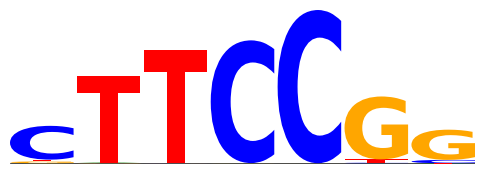

AP,ARNT,BCL,BHLH,CEBP,CLOCK,CREB,ELF,ETV,FOS,FOX,GMEB,HIVEP,HOX,JUN,KLF,MAF,MAX,MAZ,MEIS,MNT,MYC,NRF,PKNOX,POU,RREB,RUNX,SP,SRF,STAT,TBP,TEAD,VEZF,WT,ZBTB,ZEB,ZFP,ZNF
(1, 30, 8)


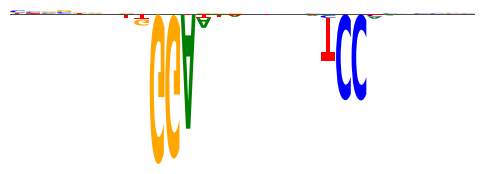

GGA
TCC


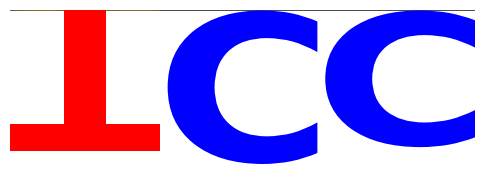

MEF2B


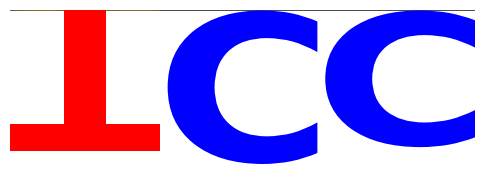

MEF2B
(1, 30, 8)


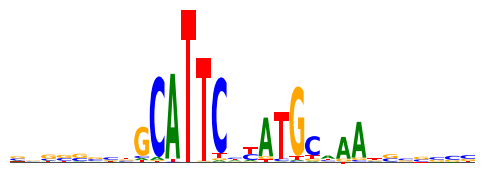

GCATTCC
TATGCAAATGCG


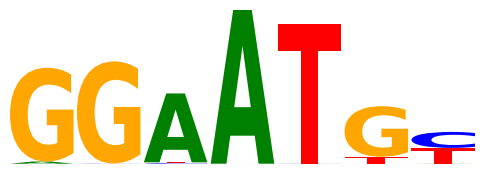

BHLHE40,BNC2,CEBPB,CREB5,ETS1,FOS,FOSL2,FOXA1,GATA3,INSM2,ISL1,JUN,JUND,MAX,NFIC,NR3C1,PBX3,RXRA,SP1,TCF12,TEAD1,TEAD2,TEAD4


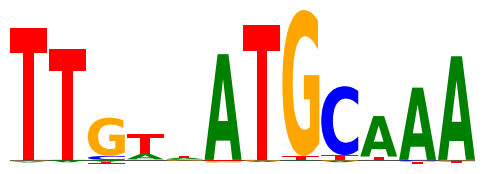

BHLH,BNC,CEBP,CREB,ETS,FOS,FOX,GATA,INSM,ISL,JUN,MAX,NFI,NR3C,PBX,RXR,SP,TCF,TEAD
(1, 30, 8)


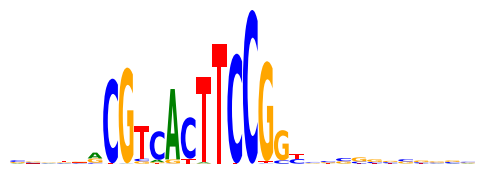

CTTCCGG
TGACGTCA


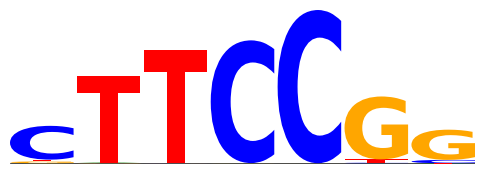

ATF1,ATF2,BATF,BCL11A,BCL3,BHLHE40,CBFB,CREB1,CREB3L1,CREM,CTCF,E2F8,E4F1,EBF1,EGR1,ELF1,ELF2,ELF4,ELK1,ELK4,ESRRA,ETS1,ETV1,ETV4,ETV5,ETV6,FOS,FOXK1,FOXK2,GABPA,GABPB1,GMEB1,HNF1B,IKZF1,IKZF2,IKZF3,IKZF5,IRF1,IRF2,JUN,JUND,KLF1,MAX,MAZ,MEF2A,MEF2C,MGA,MNT,MXI1,MYC,NFATC3,NR2C1,NR2C2,NR2F2,PAX5,POU2F1,POU2F2,PRDM15,RELA,RELB,REST,RUNX3,SIX5,SOX6,SP1,SP2,SPDEF,SRF,TBP,TBX21,TCF12,TCF3,TFDP1,TFDP2,THAP11,YY1,ZBED1,ZBTB11,ZBTB25,ZBTB33,ZBTB40,ZEB2,ZFY,ZHX2,ZNF143,ZNF175,ZNF189,ZNF217,ZNF221,ZNF281,ZNF384,ZNF395,ZNF444,ZNF501,ZNF518A,ZNF574,ZNF580,ZNF605,ZNF629,ZNF639,ZNF687,ZNF76,ZNF766,ZNF788


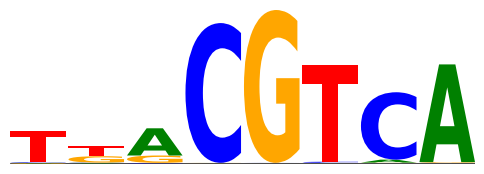

ATF,BATF,BCL,BHLH,CBFB,CREB,CREM,CTCF,DP,E2F,E4F,EBF,EGR,ELF,ELK,ESRR,ETS,ETV,FOS,FOX,GABP,GMEB,HNF1B,IKZF,IRF,JUN,KLF,MAX,MAZ,MEF2A,MEF2C,MGA,MNT,MYC,NFAT,NR2C,NR2F,PAX,POU,PRDM,REL,REST,RUNX,SIX,SOX,SP,SRF,TBP,TBX,TCF,THAP,YY,ZBED,ZBTB,ZEB,ZFY,ZHX,ZNF
(1, 30, 8)


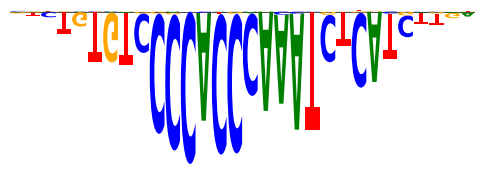

CCCCACCC
AAATCTCATC


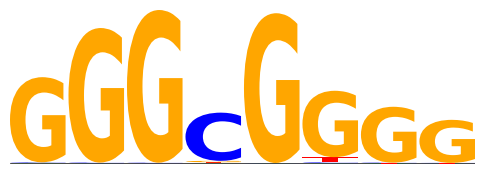

ARNT2,BCL3,BHLHE40,CEBPB,CLOCK,CREB1,ELF1,ETV6,FOS,FOXK1,GMEB1,HIVEP1,HOXA5,JUN,JUND,KLF1,KLF10,KLF12,KLF13,KLF16,KLF17,KLF4,KLF6,KLF7,KLF8,KLF9,MAFK,MAX,MAZ,MEIS2,MNT,MXI1,MYC,NRF1,PKNOX1,POU2F1,POU2F2,RREB1,RUNX3,SP1,SP2,SP3,SP4,SP5,SP7,SPDEF,SRF,STAT3,TBP,TEAD1,TFAP4,VEZF1,WT1,ZBTB17,ZEB2,ZFP90,ZNF143,ZNF221,ZNF274,ZNF341,ZNF384,ZNF407,ZNF414,ZNF430,ZNF444,ZNF547,ZNF561,ZNF605,ZNF784,ZNF788


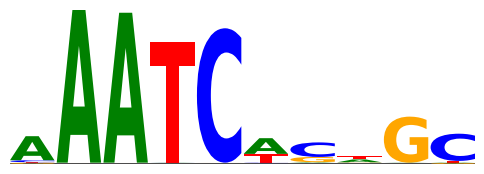

AP,ARNT,BCL,BHLH,CEBP,CLOCK,CREB,ELF,ETV,FOS,FOX,GMEB,HIVEP,HOX,JUN,KLF,MAF,MAX,MAZ,MEIS,MNT,MYC,NRF,PKNOX,POU,RREB,RUNX,SP,SRF,STAT,TBP,TEAD,VEZF,WT,ZBTB,ZEB,ZFP,ZNF
(1, 30, 8)


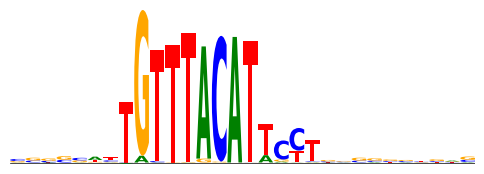

TGTTTAC
ATTCCT


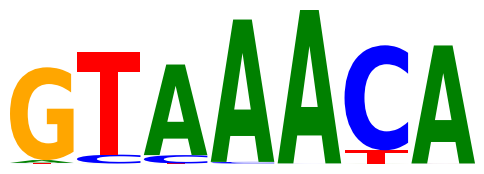

ARNT2,ARNTL,ATF1,ATF2,ATF3,ATF4,BCL3,BCL6,BHLHE40,CBFB,CEBPA,CEBPB,CEBPD,CEBPG,CLOCK,CREB1,CREM,CUX1,E2F8,EGR1,ELF1,ELK1,ESR1,ESRRA,ETS1,ETV4,ETV5,ETV6,FEZF1,FOS,FOSL1,FOSL2,FOXA1,FOXA2,FOXA3,FOXF2,FOXJ2,FOXJ3,FOXK1,FOXK2,FOXO1,FOXP4,FOXQ1,FOXS1,GATA2,GATA3,GATA4,GFI1,GLIS1,HES2,HIC2,HIVEP1,HLF,HNF1A,HNF1B,HNF4A,HNF4G,HOXA5,HOXD1,IKZF5,IRF2,JUN,JUND,KLF16,KLF4,KLF6,KLF9,MAX,MAZ,MEIS1,MEIS2,MGA,MLX,MNT,MXI1,MYC,MYPOP,NFIA,NFIB,NFIC,NFIL3,NR2F1,NR2F2,NR2F6,NR3C1,NR5A1,NR5A2,ONECUT1,ONECUT2,OSR2,OVOL1,PATZ1,PITX1,POU2F1,PPARG,PRDM1,PRDM10,REST,RFX1,RREB1,RXRA,RXRB,SIX1,SIX4,SOX13,SOX5,SOX6,SP1,SP5,SPDEF,SRF,TBX3,TCF7,TCF7L2,TEAD1,TEAD4,TFAP4,TFDP1,TFDP2,TFE3,TGIF2,THAP11,THRA,TP53,WT1,YY1,ZBED4,ZBTB10,ZBTB25,ZBTB26,ZBTB33,ZBTB37,ZBTB43,ZBTB7B,ZEB1,ZFHX3,ZFP1,ZFP37,ZFP90,ZHX1,ZHX3,ZKSCAN8,ZMYM2,ZNF12,ZNF121,ZNF124,ZNF18,ZNF181,ZNF205,ZNF217,ZNF219,ZNF221,ZNF232,ZNF264,ZNF280D,ZNF281,ZNF292,ZNF3,ZNF317,ZNF331,ZNF350,ZNF362,ZNF384,ZNF414,ZNF430,ZNF431,ZNF441,ZNF48,ZNF483,ZNF501,ZNF503,ZNF511

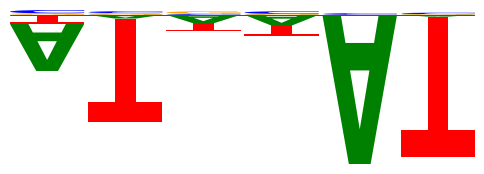

AP,ARNT,ATF,BCL,BHLH,CBFB,CEBP,CLOCK,CREB,CREM,CUX,DP,E,E2F,EGR,ELF,ELK,ESR,ESRR,ETS,ETV,FEZF,FOS,FOX,GATA,GFI,GLIS,HES,HIC,HIVEP,HLF,HNF1A,HNF1B,HNF4A,HNF4G,HOX,IKZF,IRF,JUN,KLF,MAX,MAZ,MEIS,MGA,MLX,MNT,MYC,MYPOP,NFI,NR2F,NR3C,NR5A,ONECUT,OSR,OVOL,PATZ,PITX,POU,PPAR,PRDM,REST,RFX,RREB,RXR,SIX,SOX,SP,SRF,TBX,TCF,TEAD,TGIF,THAP,THRA,TP,WT,YY,ZBED,ZBTB,ZBTB7B,ZEB,ZFHX,ZFP,ZHX,ZKSCAN,ZMYM,ZNF,ZSCAN
(1, 30, 8)


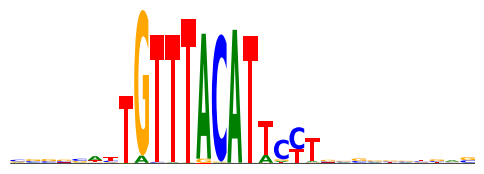

TGTTTAC
ATTCCT


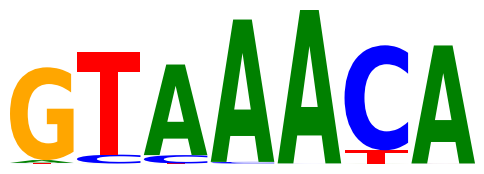

ARNT2,ARNTL,ATF1,ATF2,ATF3,ATF4,BCL3,BCL6,BHLHE40,CBFB,CEBPA,CEBPB,CEBPD,CEBPG,CLOCK,CREB1,CREM,CUX1,E2F8,EGR1,ELF1,ELK1,ESR1,ESRRA,ETS1,ETV4,ETV5,ETV6,FEZF1,FOS,FOSL1,FOSL2,FOXA1,FOXA2,FOXA3,FOXF2,FOXJ2,FOXJ3,FOXK1,FOXK2,FOXO1,FOXP4,FOXQ1,FOXS1,GATA2,GATA3,GATA4,GFI1,GLIS1,HES2,HIC2,HIVEP1,HLF,HNF1A,HNF1B,HNF4A,HNF4G,HOXA5,HOXD1,IKZF5,IRF2,JUN,JUND,KLF16,KLF4,KLF6,KLF9,MAX,MAZ,MEIS1,MEIS2,MGA,MLX,MNT,MXI1,MYC,MYPOP,NFIA,NFIB,NFIC,NFIL3,NR2F1,NR2F2,NR2F6,NR3C1,NR5A1,NR5A2,ONECUT1,ONECUT2,OSR2,OVOL1,PATZ1,PITX1,POU2F1,PPARG,PRDM1,PRDM10,REST,RFX1,RREB1,RXRA,RXRB,SIX1,SIX4,SOX13,SOX5,SOX6,SP1,SP5,SPDEF,SRF,TBX3,TCF7,TCF7L2,TEAD1,TEAD4,TFAP4,TFDP1,TFDP2,TFE3,TGIF2,THAP11,THRA,TP53,WT1,YY1,ZBED4,ZBTB10,ZBTB25,ZBTB26,ZBTB33,ZBTB37,ZBTB43,ZBTB7B,ZEB1,ZFHX3,ZFP1,ZFP37,ZFP90,ZHX1,ZHX3,ZKSCAN8,ZMYM2,ZNF12,ZNF121,ZNF124,ZNF18,ZNF181,ZNF205,ZNF217,ZNF219,ZNF221,ZNF232,ZNF264,ZNF280D,ZNF281,ZNF292,ZNF3,ZNF317,ZNF331,ZNF350,ZNF362,ZNF384,ZNF414,ZNF430,ZNF431,ZNF441,ZNF48,ZNF483,ZNF501,ZNF503,ZNF511

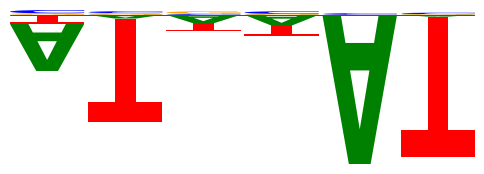

AP,ARNT,ATF,BCL,BHLH,CBFB,CEBP,CLOCK,CREB,CREM,CUX,DP,E,E2F,EGR,ELF,ELK,ESR,ESRR,ETS,ETV,FEZF,FOS,FOX,GATA,GFI,GLIS,HES,HIC,HIVEP,HLF,HNF1A,HNF1B,HNF4A,HNF4G,HOX,IKZF,IRF,JUN,KLF,MAX,MAZ,MEIS,MGA,MLX,MNT,MYC,MYPOP,NFI,NR2F,NR3C,NR5A,ONECUT,OSR,OVOL,PATZ,PITX,POU,PPAR,PRDM,REST,RFX,RREB,RXR,SIX,SOX,SP,SRF,TBX,TCF,TEAD,TGIF,THAP,THRA,TP,WT,YY,ZBED,ZBTB,ZBTB7B,ZEB,ZFHX,ZFP,ZHX,ZKSCAN,ZMYM,ZNF,ZSCAN
(1, 30, 8)


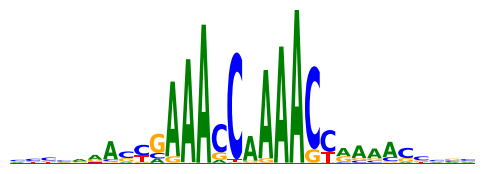

AACCGAAACCAAAA
CCAAAACC


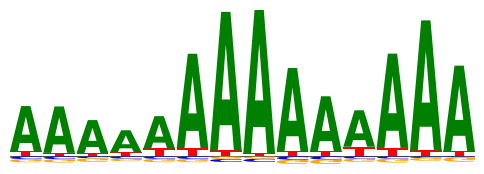

CTCF,ZNF615


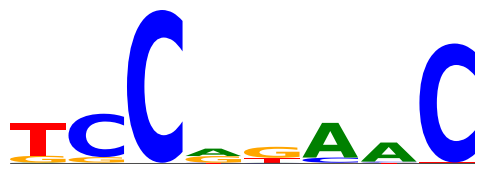

CTCF,ZNF
(1, 30, 8)


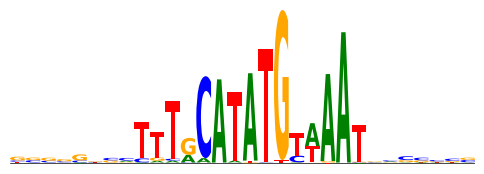

TGCATATGTAAAT
GGGGCCTTAAAA


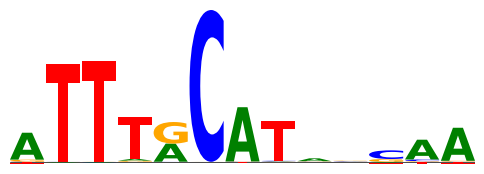

FOXK1,FOXP4,POU2F1


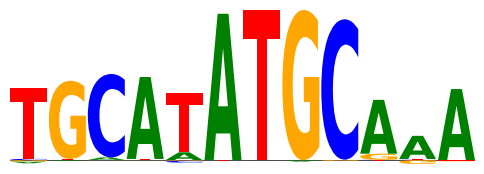

FOX,POU
(1, 30, 8)


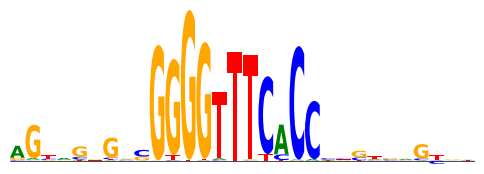

CGGGGTTTCAC
CCCGTGAGTG


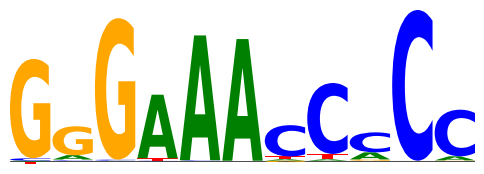

BCL3


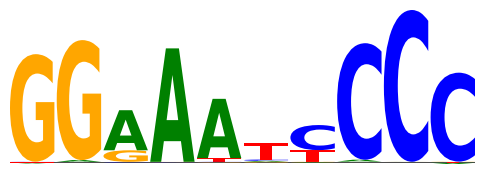

BCL
(1, 30, 8)


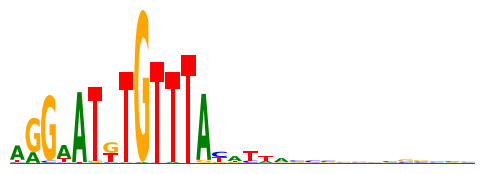

TGTTTAC
GAATGAAAAAAAATTACCCGGGCGGGC


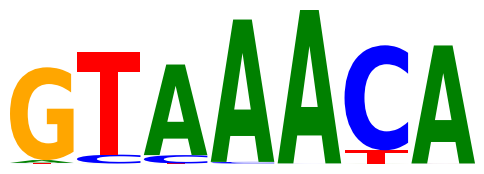

ARNT2,ARNTL,ATF1,ATF2,ATF3,ATF4,BCL3,BCL6,BHLHE40,CBFB,CEBPA,CEBPB,CEBPD,CEBPG,CLOCK,CREB1,CREM,CUX1,E2F8,EGR1,ELF1,ELK1,ESR1,ESRRA,ETS1,ETV4,ETV5,ETV6,FEZF1,FOS,FOSL1,FOSL2,FOXA1,FOXA2,FOXA3,FOXF2,FOXJ2,FOXJ3,FOXK1,FOXK2,FOXO1,FOXP4,FOXQ1,FOXS1,GATA2,GATA3,GATA4,GFI1,GLIS1,HES2,HIC2,HIVEP1,HLF,HNF1A,HNF1B,HNF4A,HNF4G,HOXA5,HOXD1,IKZF5,IRF2,JUN,JUND,KLF16,KLF4,KLF6,KLF9,MAX,MAZ,MEIS1,MEIS2,MGA,MLX,MNT,MXI1,MYC,MYPOP,NFIA,NFIB,NFIC,NFIL3,NR2F1,NR2F2,NR2F6,NR3C1,NR5A1,NR5A2,ONECUT1,ONECUT2,OSR2,OVOL1,PATZ1,PITX1,POU2F1,PPARG,PRDM1,PRDM10,REST,RFX1,RREB1,RXRA,RXRB,SIX1,SIX4,SOX13,SOX5,SOX6,SP1,SP5,SPDEF,SRF,TBX3,TCF7,TCF7L2,TEAD1,TEAD4,TFAP4,TFDP1,TFDP2,TFE3,TGIF2,THAP11,THRA,TP53,WT1,YY1,ZBED4,ZBTB10,ZBTB25,ZBTB26,ZBTB33,ZBTB37,ZBTB43,ZBTB7B,ZEB1,ZFHX3,ZFP1,ZFP37,ZFP90,ZHX1,ZHX3,ZKSCAN8,ZMYM2,ZNF12,ZNF121,ZNF124,ZNF18,ZNF181,ZNF205,ZNF217,ZNF219,ZNF221,ZNF232,ZNF264,ZNF280D,ZNF281,ZNF292,ZNF3,ZNF317,ZNF331,ZNF350,ZNF362,ZNF384,ZNF414,ZNF430,ZNF431,ZNF441,ZNF48,ZNF483,ZNF501,ZNF503,ZNF511

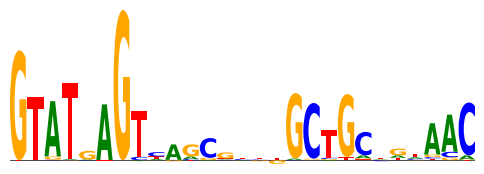

AP,ARNT,ATF,BCL,BHLH,CBFB,CEBP,CLOCK,CREB,CREM,CUX,DP,E,E2F,EGR,ELF,ELK,ESR,ESRR,ETS,ETV,FEZF,FOS,FOX,GATA,GFI,GLIS,HES,HIC,HIVEP,HLF,HNF1A,HNF1B,HNF4A,HNF4G,HOX,IKZF,IRF,JUN,KLF,MAX,MAZ,MEIS,MGA,MLX,MNT,MYC,MYPOP,NFI,NR2F,NR3C,NR5A,ONECUT,OSR,OVOL,PATZ,PITX,POU,PPAR,PRDM,REST,RFX,RREB,RXR,SIX,SOX,SP,SRF,TBX,TCF,TEAD,TGIF,THAP,THRA,TP,WT,YY,ZBED,ZBTB,ZBTB7B,ZEB,ZFHX,ZFP,ZHX,ZKSCAN,ZMYM,ZNF,ZSCAN
(1, 30, 8)


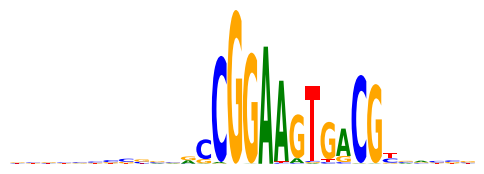

CCGGAAG
TGACGTGA


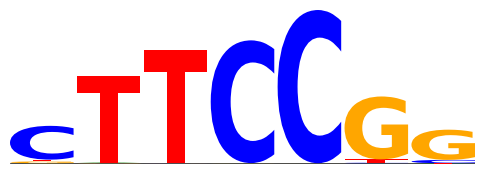

ATF1,ATF2,BATF,BCL11A,BCL3,BHLHE40,CBFB,CREB1,CREB3L1,CREM,CTCF,E2F8,E4F1,EBF1,EGR1,ELF1,ELF2,ELF4,ELK1,ELK4,ESRRA,ETS1,ETV1,ETV4,ETV5,ETV6,FOS,FOXK1,FOXK2,GABPA,GABPB1,GMEB1,HNF1B,IKZF1,IKZF2,IKZF3,IKZF5,IRF1,IRF2,JUN,JUND,KLF1,MAX,MAZ,MEF2A,MEF2C,MGA,MNT,MXI1,MYC,NFATC3,NR2C1,NR2C2,NR2F2,PAX5,POU2F1,POU2F2,PRDM15,RELA,RELB,REST,RUNX3,SIX5,SOX6,SP1,SP2,SPDEF,SRF,TBP,TBX21,TCF12,TCF3,TFDP1,TFDP2,THAP11,YY1,ZBED1,ZBTB11,ZBTB25,ZBTB33,ZBTB40,ZEB2,ZFY,ZHX2,ZNF143,ZNF175,ZNF189,ZNF217,ZNF221,ZNF281,ZNF384,ZNF395,ZNF444,ZNF501,ZNF518A,ZNF574,ZNF580,ZNF605,ZNF629,ZNF639,ZNF687,ZNF76,ZNF766,ZNF788


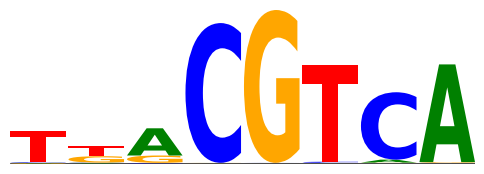

ATF,BATF,BCL,BHLH,CBFB,CREB,CREM,CTCF,DP,E2F,E4F,EBF,EGR,ELF,ELK,ESRR,ETS,ETV,FOS,FOX,GABP,GMEB,HNF1B,IKZF,IRF,JUN,KLF,MAX,MAZ,MEF2A,MEF2C,MGA,MNT,MYC,NFAT,NR2C,NR2F,PAX,POU,PRDM,REL,REST,RUNX,SIX,SOX,SP,SRF,TBP,TBX,TCF,THAP,YY,ZBED,ZBTB,ZEB,ZFY,ZHX,ZNF
(1, 30, 8)


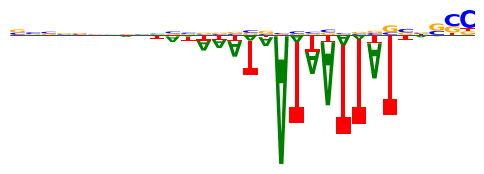

error
(1, 30, 8)


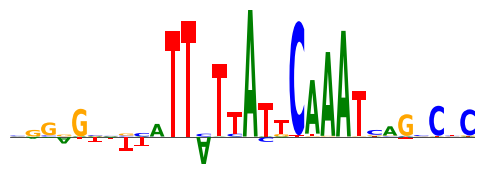

TTATTATTCAAA
TCAGCCTC


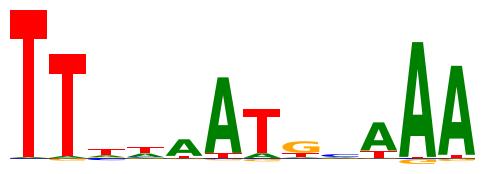

ATF2,BCL11A


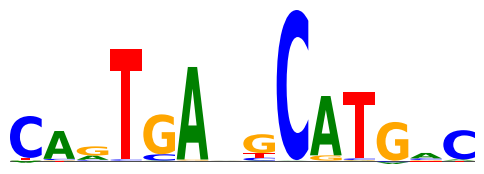

ATF,BCL
(1, 30, 8)


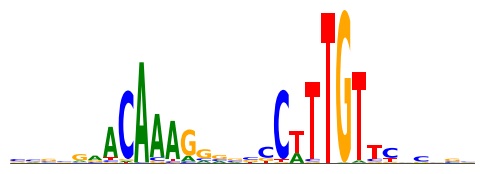

CCTTTGTT
AACAAAGG


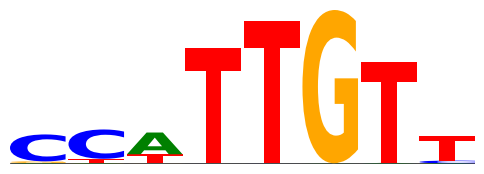

SOX13,SOX5,SOX6


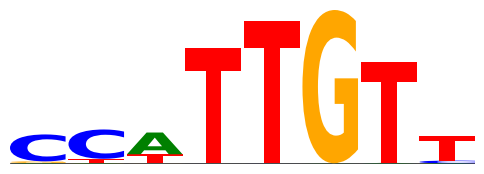

SOX
(1, 30, 8)


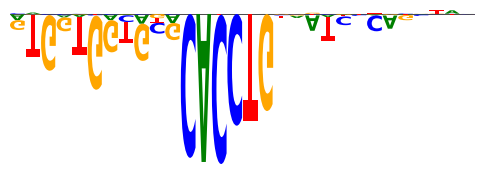

CACCTG
GT


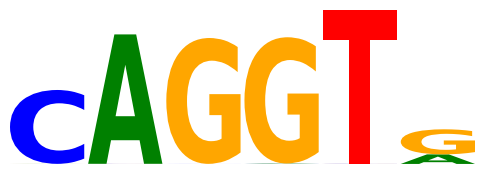

ZEB1,ZEB2


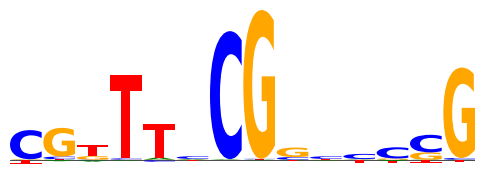

ZEB
(1, 30, 8)


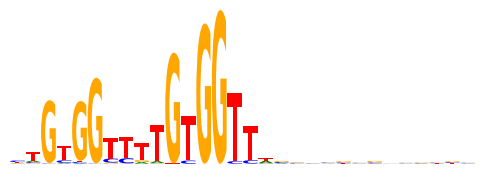

TGTGGTT
TGTGGTT


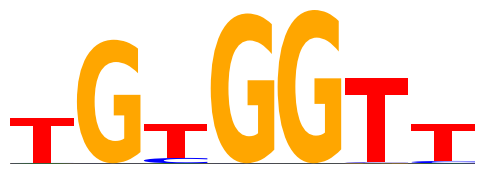

ARNT,ATF2,BATF,BCL11A,BHLHE40,BMI1,CBFB,CREB1,CREM,EBF1,ESRRA,ETV6,GATA3,HES1,IKZF1,IKZF2,IRF4,JUND,MAX,MEF2A,MEF2B,MEF2C,MYC,NFATC3,NFIC,NR2F1,PAX5,PBX3,POU2F2,RELA,RELB,RUNX1,RUNX3,SP1,TBX21,TCF12,TCF3,TCF7,TEAD1,TEAD4,ZBED1,ZNF217,ZNF24,ZNF687


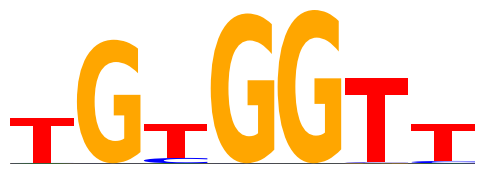

ARNT,ATF,BATF,BCL,BHLH,BMI,CBFB,CREB,CREM,EBF,ESRR,ETV,GATA,HES,IKZF,IRF,JUN,MAX,MEF2A,MEF2B,MEF2C,MYC,NFAT,NFI,NR2F,PAX,PBX,POU,REL,RUNX,SP,TBX,TCF,TEAD,ZBED,ZNF
(1, 30, 8)


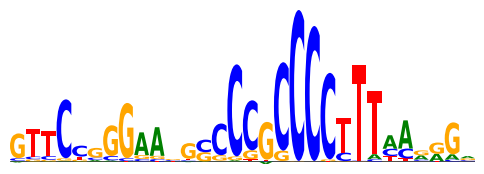

TTCCGGGAAGGCCCCGCCCC
TTTAAGGG


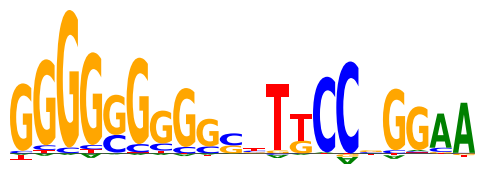

STAT3


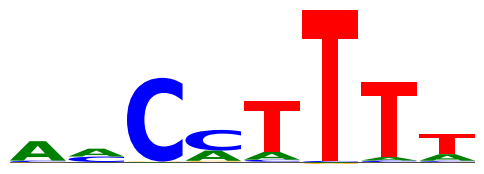

STAT
(1, 30, 8)


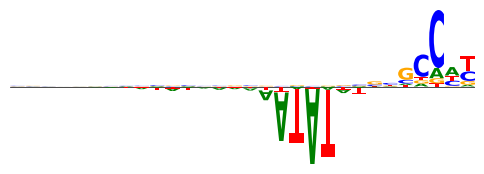

AATATATGC
TATAAAAAAAAAAAAAGCCAT


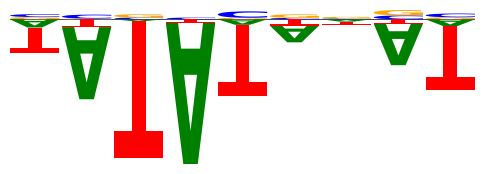

FOSL2


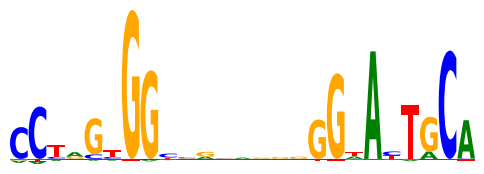

FOS
(1, 30, 8)


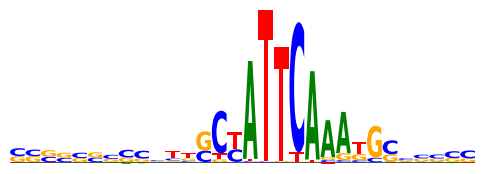

CTATTCA
AATGCCCCC


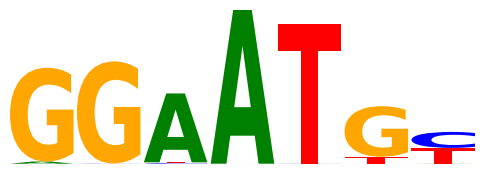

BHLHE40,BNC2,CEBPB,CREB5,ETS1,FOS,FOSL2,FOXA1,GATA3,INSM2,ISL1,JUN,JUND,MAX,NFIC,NR3C1,PBX3,RXRA,SP1,TCF12,TEAD1,TEAD2,TEAD4


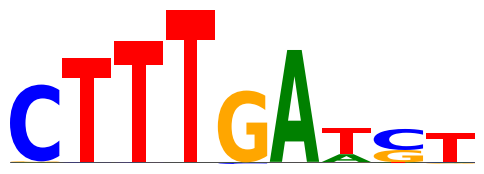

BHLH,BNC,CEBP,CREB,ETS,FOS,FOX,GATA,INSM,ISL,JUN,MAX,NFI,NR3C,PBX,RXR,SP,TCF,TEAD
(1, 30, 8)


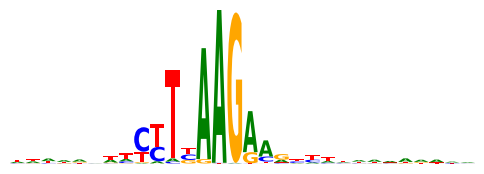

AATTCTTTAAGAAGTT
TTAAAA


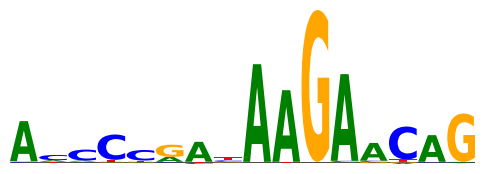

ZNF677


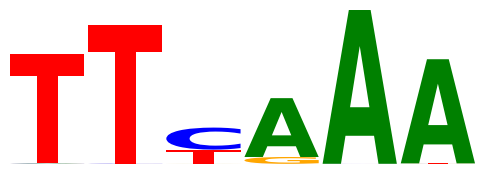

ZNF
(1, 30, 8)


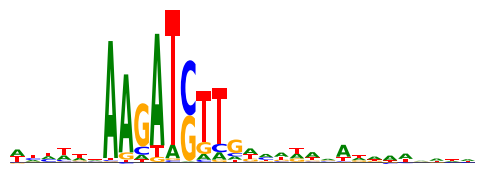

TAAGATCT
TGAAATAAATAAAAAT


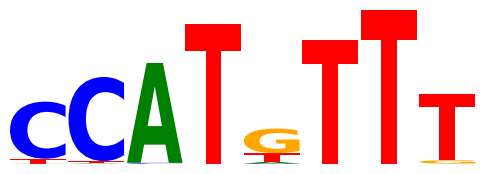

YY1


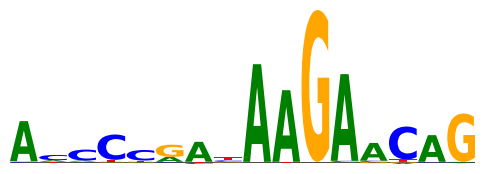

YY
(1, 30, 8)


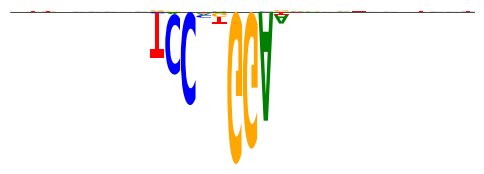

GGA
TCC


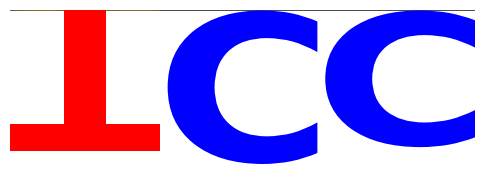

MEF2B


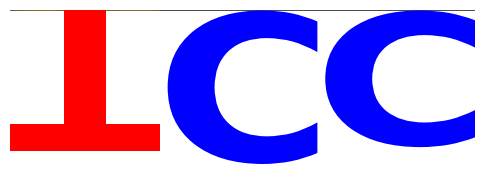

MEF2B
(1, 30, 8)


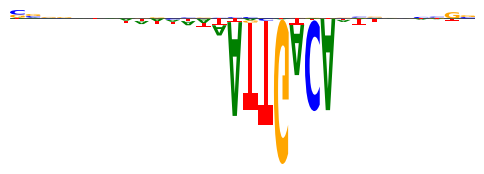

AATTGAC
AATTTT


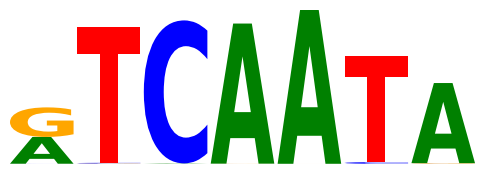

BCL6,CEBPA,CUX1,HNF4A,NR2F2,ONECUT2,SOX6,TCF7L2,ZNF217,ZNF219


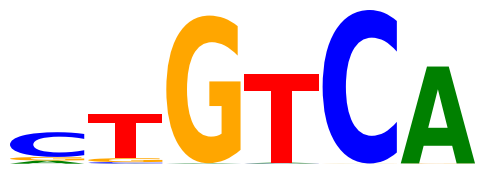

BCL,CEBP,CUX,HNF4A,NR2F,ONECUT,SOX,TCF,ZNF
(1, 30, 8)


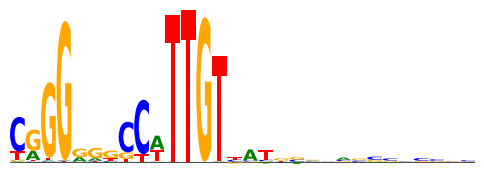

CCATTGTT
C


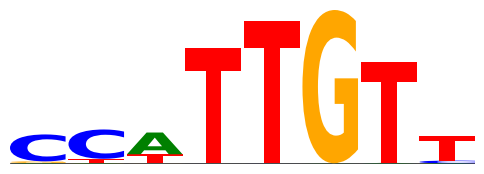

SOX13,SOX5,SOX6


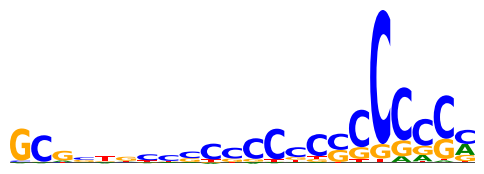

SOX
(1, 30, 8)


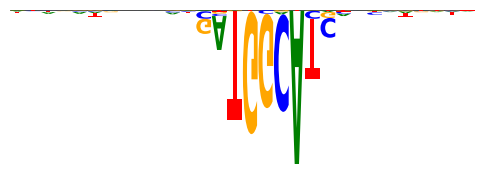

TGGCA
GAAAAAATC


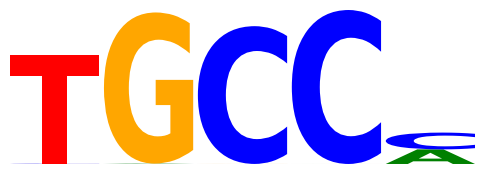

HIC1,HIC2


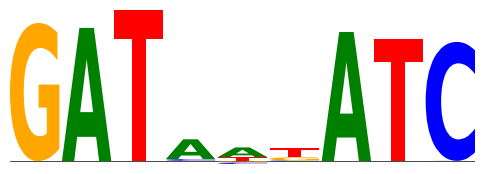

HIC
(1, 30, 8)


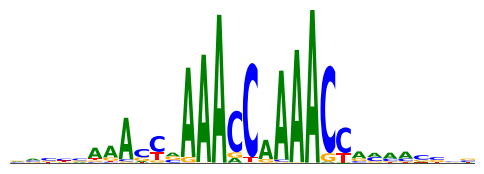

AACCAAAACCAAAA
CCAAAACC


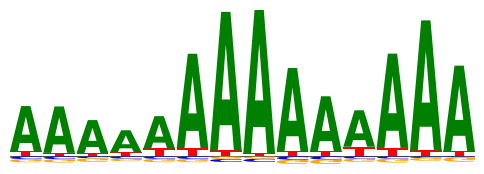

CTCF,ZNF615


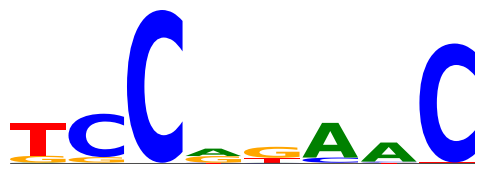

CTCF,ZNF
(1, 30, 8)


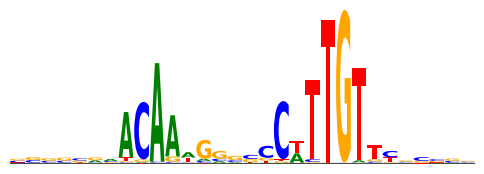

CCTTTGTT
AACAAAGG


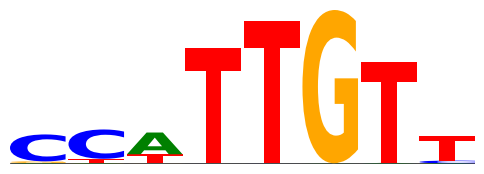

SOX13,SOX5,SOX6


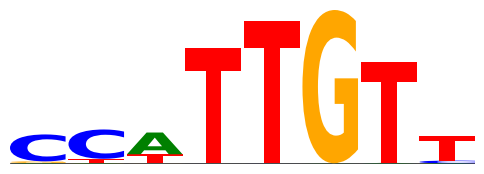

SOX
(1, 30, 8)


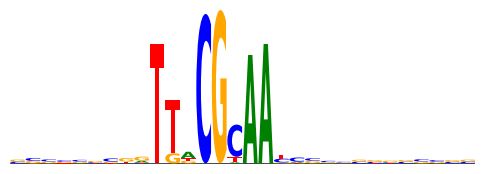

TTACGCAA
CCGCGG


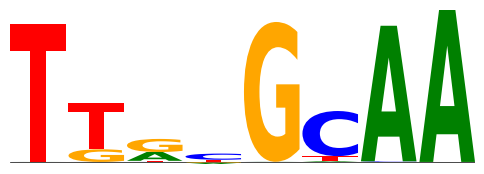

ADNP,ARNT2,ARNTL,ATF2,ATF3,ATF4,BCL3,BCL6,CBFB,CEBPA,CEBPB,CEBPD,CEBPG,CREB1,CREM,DDIT3,E2F8,EGR1,ELF1,ESRRA,ETS1,ETV4,ETV5,ETV6,FOS,FOSL1,FOSL2,FOXA1,FOXA2,FOXA3,FOXF2,FOXJ3,FOXK1,FOXO1,FOXP4,FOXQ1,GATA2,GATA4,GFI1,HES2,HIVEP1,HLF,HNF1A,HNF1B,HNF4A,HNF4G,HOXA5,HOXD1,HSF1,IKZF5,IRF2,JUN,JUND,KLF16,KLF6,MAFF,MAFK,MAX,MAZ,MEIS1,MEIS2,MLX,MYC,MYPOP,NFE2L2,NFIA,NFIC,NFIL3,NR2C2,NR2F1,NR2F2,NR2F6,NR3C1,NR5A1,ONECUT1,ONECUT2,PATZ1,PITX1,POU2F1,PPARG,PRDM1,RELA,REST,RREB1,RXRA,RXRB,SIX1,SIX4,SOX13,SOX5,SOX6,SP1,SP5,SPDEF,SRF,STAT3,TBP,TCF7,TCF7L2,TEAD1,TEAD4,TEF,TFAP4,TFE3,TGIF2,THAP11,THRA,USF2,YY1,ZBED4,ZBTB25,ZBTB26,ZBTB33,ZBTB43,ZBTB7B,ZEB1,ZFHX3,ZFP1,ZFP90,ZHX1,ZHX3,ZKSCAN8,ZMYM2,ZNF12,ZNF121,ZNF124,ZNF205,ZNF217,ZNF219,ZNF264,ZNF280D,ZNF281,ZNF292,ZNF3,ZNF331,ZNF350,ZNF362,ZNF384,ZNF414,ZNF430,ZNF431,ZNF460,ZNF48,ZNF503,ZNF511,ZNF512B,ZNF543,ZNF556,ZNF564,ZNF580,ZNF605,ZNF609,ZNF614,ZNF644,ZNF670,ZNF710,ZNF746,ZNF747,ZNF749,ZNF770,ZNF772,ZNF788,ZNF792,ZNF865,ZNF878,ZSCAN9


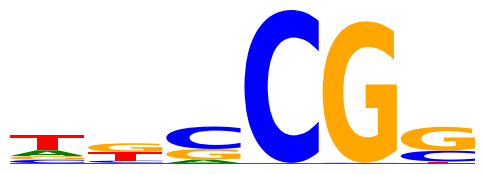

ADNP,AP,ARNT,ATF,BCL,CBFB,CEBP,CREB,CREM,DDIT,E,E2F,EGR,ELF,ESRR,ETS,ETV,FOS,FOX,GATA,GFI,HES,HIVEP,HLF,HNF1A,HNF1B,HNF4A,HNF4G,HOX,HSF,IKZF,IRF,JUN,KLF,MAF,MAX,MAZ,MEIS,MLX,MYC,MYPOP,NFE,NFI,NR2C,NR2F,NR3C,NR5A,ONECUT,PATZ,PITX,POU,PPAR,PRDM,REL,REST,RREB,RXR,SIX,SOX,SP,SRF,STAT,TBP,TCF,TEAD,TEF,TGIF,THAP,THRA,USF,YY,ZBED,ZBTB,ZBTB7B,ZEB,ZFHX,ZFP,ZHX,ZKSCAN,ZMYM,ZNF,ZSCAN
(1, 30, 8)


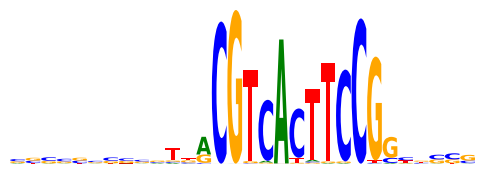

CGTCACTTCCGG
CCGCCCCGTTAAA


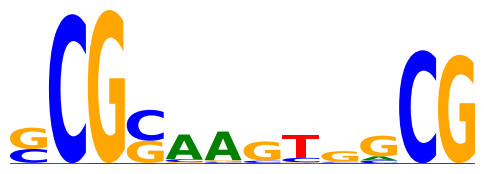

ATF1,BCL3,CTCF,IRF1,JUN,ZBTB33,ZHX2,ZNF24,ZNF772


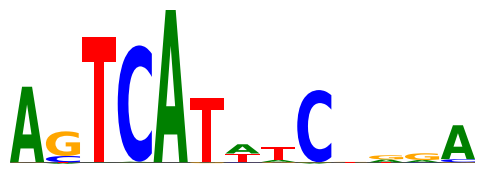

ATF,BCL,CTCF,IRF,JUN,ZBTB,ZHX,ZNF
(1, 30, 8)


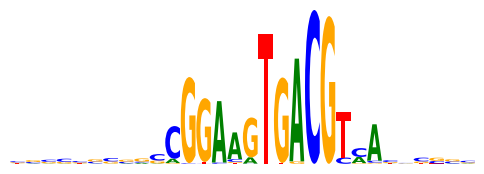

TGACGTCA
CCGGAAG


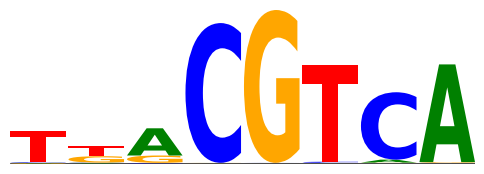

ATF1,ATF2,ATF3,ATF4,BCL3,BHLHE40,CEBPB,CLOCK,CREB1,CREM,E2F8,ELF1,ELF2,FOS,FOSL2,FOXA1,FOXA2,GABPA,GABPB1,GMEB1,JUN,JUND,KLF16,MAFF,MAX,MAZ,MNT,MYC,NFE2L2,NFIB,NFYB,NR3C1,OVOL1,PAX8,POU2F1,RELA,RFX5,SP1,SP4,SRF,STAT3,TBP,THAP11,USF2,ZBTB12,ZEB2,ZHX1,ZHX2,ZHX3,ZNF2,ZNF217,ZNF395,ZNF501,ZNF565,ZNF629,ZNF639,ZNF76


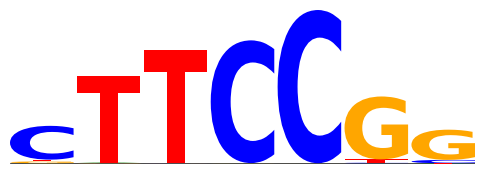

ATF,BCL,BHLH,CEBP,CLOCK,CREB,CREM,E2F,ELF,FOS,FOX,GABP,GMEB,JUN,KLF,MAF,MAX,MAZ,MNT,MYC,NFE,NFI,NFY,NR3C,OVOL,PAX,POU,REL,RFX,SP,SRF,STAT,TBP,THAP,USF,ZBTB,ZEB,ZHX,ZNF
(1, 30, 8)


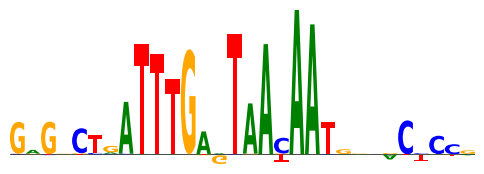

TTTGAGTAACAA
GAG


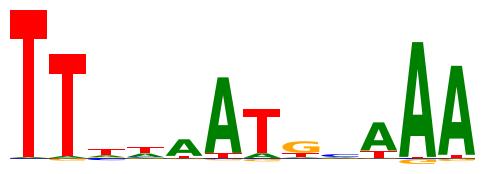

ATF2,BCL11A


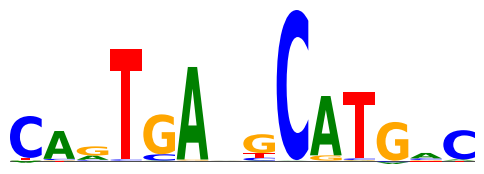

ATF,BCL
(1, 30, 8)


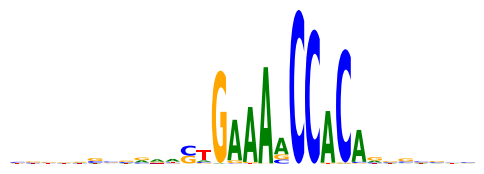

AACCACA
GGAACTGAAAA


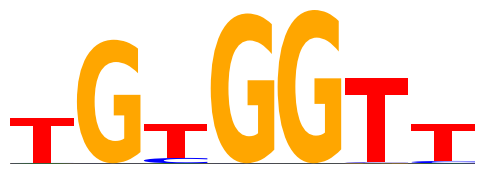

ARNT,ATF2,BATF,BCL11A,BHLHE40,BMI1,CBFB,CREB1,CREM,EBF1,ESRRA,ETV6,GATA3,HES1,IKZF1,IKZF2,IRF4,JUND,MAX,MEF2A,MEF2B,MEF2C,MYC,NFATC3,NFIC,NR2F1,PAX5,PBX3,POU2F2,RELA,RELB,RUNX1,RUNX3,SP1,TBX21,TCF12,TCF3,TCF7,TEAD1,TEAD4,ZBED1,ZNF217,ZNF24,ZNF687


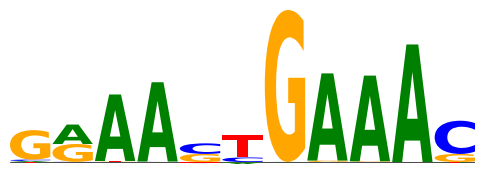

ARNT,ATF,BATF,BCL,BHLH,BMI,CBFB,CREB,CREM,EBF,ESRR,ETV,GATA,HES,IKZF,IRF,JUN,MAX,MEF2A,MEF2B,MEF2C,MYC,NFAT,NFI,NR2F,PAX,PBX,POU,REL,RUNX,SP,TBX,TCF,TEAD,ZBED,ZNF
(1, 30, 8)


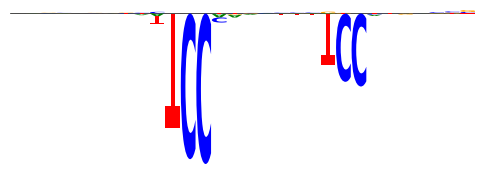

TCC
TCC


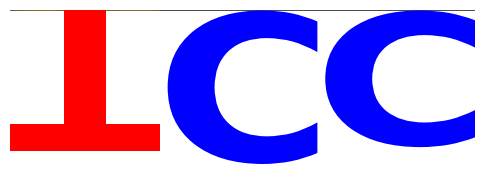

MEF2B


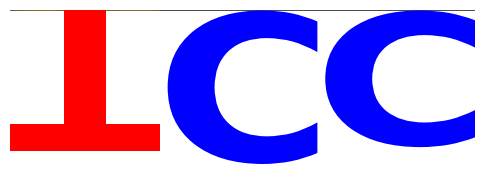

MEF2B
(1, 30, 8)


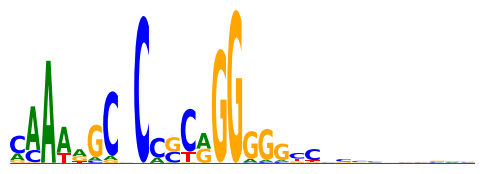

CCCCGCAGGGG
CAAAAGAA


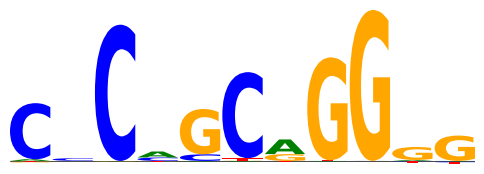

GLIS1,NFIC,OTX2,PRDM6,TEAD1,TEAD4,ZIC2,ZNF423,ZNF462


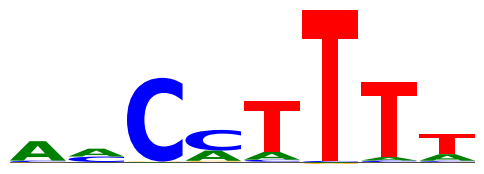

GLIS,NFI,OTX,PRDM,TEAD,ZIC,ZNF
(1, 30, 8)


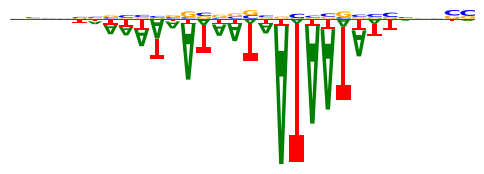

TAATAATATT
AAAATAATAAAAAAAAAAA


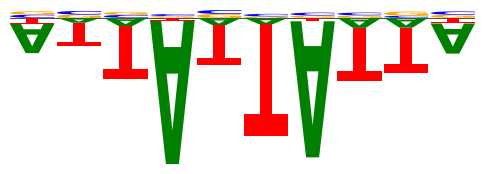

JUND,MEF2D,NFE2,ZNF24


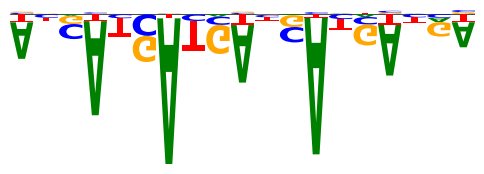

JUN,MEF2D,NFE,ZNF
(1, 30, 8)


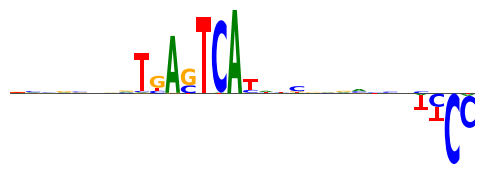

TGAGTCA
TATCGAGACCCTTCC


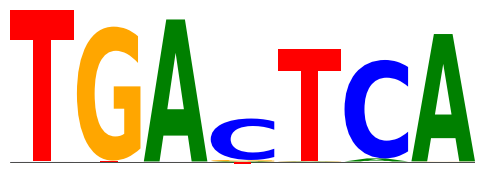

ADNP,ARNT,ATF1,ATF2,ATF3,ATF4,ATOH8,BACH1,BATF,BCL11A,BCL3,BCL6B,BHLHE40,BMI1,BNC2,CBFB,CEBPA,CEBPB,CEBPG,CLOCK,CREB1,CREB5,CREM,CUX1,E2F4,E2F5,E2F6,E4F1,EBF1,EGR1,EGR2,ELF1,ELF4,ESR1,ESRRA,ETS1,ETV1,ETV4,ETV5,ETV6,FEZF1,FOS,FOSL1,FOSL2,FOXA1,FOXA2,FOXA3,FOXF2,FOXJ2,FOXK1,FOXK2,FOXP4,FOXS1,GABPA,GATA2,GATA3,GFI1B,GLI2,GLIS1,GLIS2,GMEB1,HES1,HES2,HIC1,HIC2,HIVEP1,HNF1B,HOXB5,HOXD13,IKZF1,IKZF2,IKZF3,IKZF5,INSM2,IRF1,IRF2,IRF4,ISL1,JUN,JUND,KLF1,KLF10,KLF16,KLF17,KLF8,MAFF,MAFK,MAX,MAZ,MEF2A,MEF2B,MEF2C,MEF2D,MEIS2,MGA,MITF,MLX,MNT,MXI1,MYC,MYNN,NFATC1,NFATC3,NFE2,NFE2L2,NFIB,NFIC,NFIL3,NR2C1,NR2C2,NR2F1,NR2F2,NR2F6,NR3C1,NR5A2,NRF1,OSR2,OVOL1,PATZ1,PAX5,PBX1,PBX2,PBX3,PKNOX1,POU2F1,POU2F2,POU6F1,PPARG,PRDM1,PRDM10,PRDM6,RBAK,RELA,RELB,REST,RFX1,RREB1,RUNX3,RXRA,RXRB,SCRT2,SOX13,SOX5,SOX6,SP1,SP3,SP5,SP7,SPDEF,SREBF1,SRF,STAT3,STAT5A,TBP,TBX21,TBX3,TCF12,TCF3,TCF7,TCF7L2,TEAD1,TEAD2,TEAD4,TFAP4,TFDP1,TFE3,USF1,USF2,VEZF1,WT1,YY1,ZBED1,ZBTB12,ZBTB17,ZBTB2,ZBTB33,ZBTB40,ZBTB48,ZBTB8A,ZEB1,

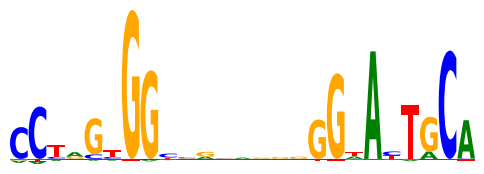

ADNP,AP,ARNT,ATF,ATOH,BACH,BATF,BCL,BHLH,BMI,BNC,CBFB,CEBP,CLOCK,CREB,CREM,CUX,DP,E,E2F,E4F,EBF,EGR,ELF,ESR,ESRR,ETS,ETV,FEZF,FOS,FOX,GABP,GATA,GFI,GLI,GLIS,GMEB,HES,HIC,HIVEP,HNF1B,HOX,IKZF,INSM,IRF,ISL,JUN,KLF,MAF,MAX,MAZ,MEF2A,MEF2B,MEF2C,MEF2D,MEIS,MGA,MITF,MLX,MNT,MYC,MYNN,NFAT,NFE,NFI,NR2C,NR2F,NR3C,NR5A,NRF,OSR,OVOL,PATZ,PAX,PBX,PKNOX,POU,PPAR,PRDM,RBAK,REL,REST,RFX,RREB,RUNX,RXR,SCRT,SOX,SP,SREBF,SRF,STAT,STAT5A,TBP,TBX,TCF,TEAD,USF,VEZF,WT,YY,ZBED,ZBTB,ZBTB8A,ZEB,ZFHX,ZFP,ZFP69B,ZHX,ZIC,ZKSCAN,ZMYM,ZNF,ZSCAN
(1, 30, 8)


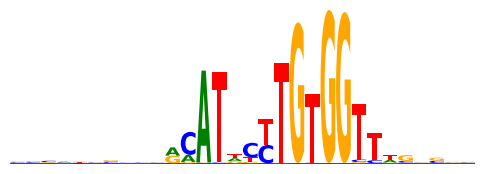

TGTGGTT
ACATTCTAAAAAAATGG


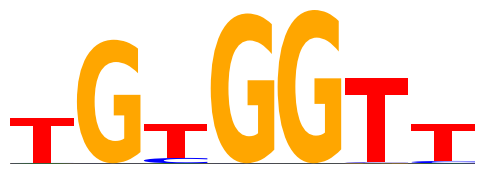

ARNT,ATF2,BATF,BCL11A,BHLHE40,BMI1,CBFB,CREB1,CREM,EBF1,ESRRA,ETV6,GATA3,HES1,IKZF1,IKZF2,IRF4,JUND,MAX,MEF2A,MEF2B,MEF2C,MYC,NFATC3,NFIC,NR2F1,PAX5,PBX3,POU2F2,RELA,RELB,RUNX1,RUNX3,SP1,TBX21,TCF12,TCF3,TCF7,TEAD1,TEAD4,ZBED1,ZNF217,ZNF24,ZNF687


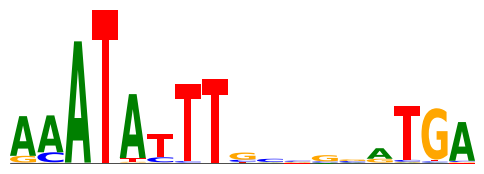

ARNT,ATF,BATF,BCL,BHLH,BMI,CBFB,CREB,CREM,EBF,ESRR,ETV,GATA,HES,IKZF,IRF,JUN,MAX,MEF2A,MEF2B,MEF2C,MYC,NFAT,NFI,NR2F,PAX,PBX,POU,REL,RUNX,SP,TBX,TCF,TEAD,ZBED,ZNF
(1, 30, 8)


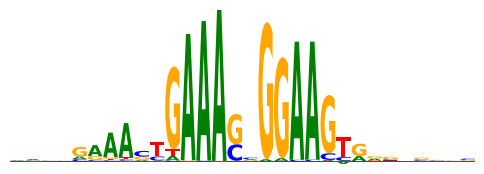

GAAAGCGGAAG
GGGAAACTAAAAA


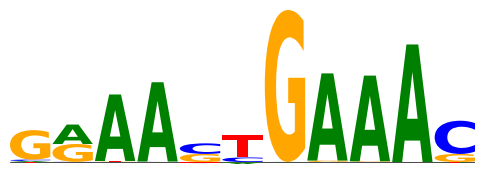

ARNT,ATF2,BACH1,BATF,BCL11A,BHLHE40,BMI1,CREB1,CREM,CUX1,EBF1,ELF1,ETV6,IKZF1,IKZF2,IRF1,IRF2,IRF4,JUND,MEF2A,MEF2B,MEF2C,MXI1,NFATC1,NFATC3,NR2F1,PAX5,PKNOX1,POU2F2,RELA,RELB,RUNX3,STAT1,TBX21,TCF12,TCF3,ZBED1,ZNF217,ZNF24,ZNF384,ZNF687


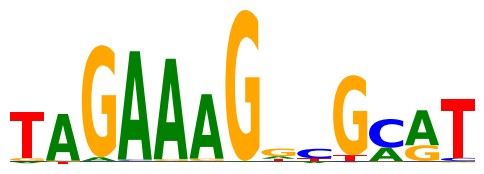

ARNT,ATF,BACH,BATF,BCL,BHLH,BMI,CREB,CREM,CUX,EBF,ELF,ETV,IKZF,IRF,JUN,MAX,MEF2A,MEF2B,MEF2C,NFAT,NR2F,PAX,PKNOX,POU,REL,RUNX,STAT,TBX,TCF,ZBED,ZNF
(1, 30, 8)


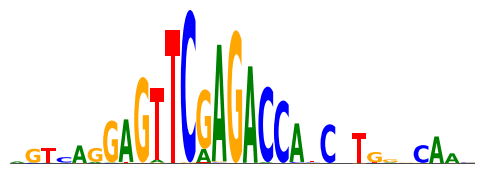

CAGGAGTTCGAGACC
ATCCTGGGCAAC


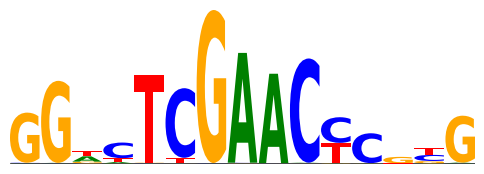

ADNP,ATF3,CEBPB,DEAF1,ETS1,FOSL2,HSF1,MAFK,SREBF2,TBP,TEAD4,ZBTB5,ZMYM2,ZNF217,ZNF24,ZNF580,ZNF764,ZSCAN29


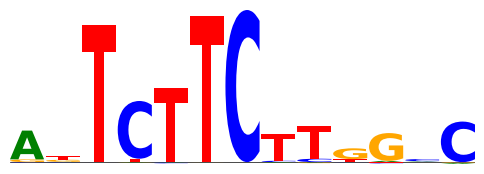

ADNP,ATF,CEBP,DEAF,ETS,FOS,HSF,MAF,SREBF,TBP,TEAD,ZBTB,ZMYM,ZNF,ZSCAN
(1, 30, 8)


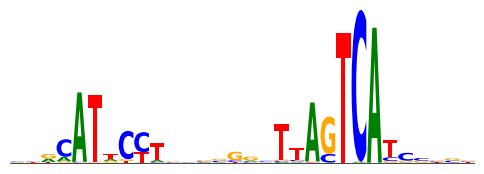

CTTAGTCAT
ATTCCTGCGGGGAAAAAAAA


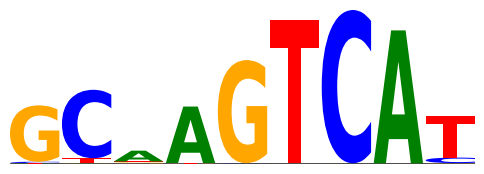

ATF3,MAFF,MAFG,MAFK,NFE2,NFE2L2,ZNF316,ZNF639


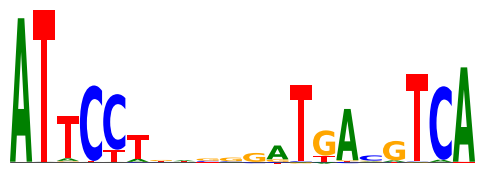

ATF,MAF,NFE,ZNF
(1, 30, 8)


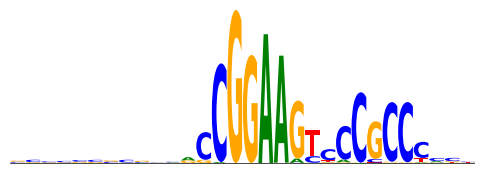

CCGGAAG
TCCCGCCC


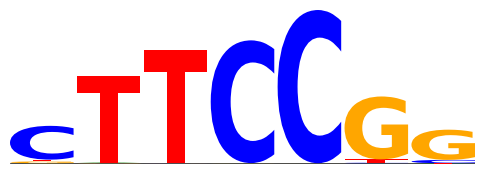

ATF1,ATF2,BATF,BCL11A,BCL3,BHLHE40,CBFB,CREB1,CREB3L1,CREM,CTCF,E2F8,E4F1,EBF1,EGR1,ELF1,ELF2,ELF4,ELK1,ELK4,ESRRA,ETS1,ETV1,ETV4,ETV5,ETV6,FOS,FOXK1,FOXK2,GABPA,GABPB1,GMEB1,HNF1B,IKZF1,IKZF2,IKZF3,IKZF5,IRF1,IRF2,JUN,JUND,KLF1,MAX,MAZ,MEF2A,MEF2C,MGA,MNT,MXI1,MYC,NFATC3,NR2C1,NR2C2,NR2F2,PAX5,POU2F1,POU2F2,PRDM15,RELA,RELB,REST,RUNX3,SIX5,SOX6,SP1,SP2,SPDEF,SRF,TBP,TBX21,TCF12,TCF3,TFDP1,TFDP2,THAP11,YY1,ZBED1,ZBTB11,ZBTB25,ZBTB33,ZBTB40,ZEB2,ZFY,ZHX2,ZNF143,ZNF175,ZNF189,ZNF217,ZNF221,ZNF281,ZNF384,ZNF395,ZNF444,ZNF501,ZNF518A,ZNF574,ZNF580,ZNF605,ZNF629,ZNF639,ZNF687,ZNF76,ZNF766,ZNF788


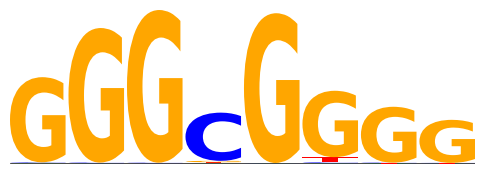

ATF,BATF,BCL,BHLH,CBFB,CREB,CREM,CTCF,DP,E2F,E4F,EBF,EGR,ELF,ELK,ESRR,ETS,ETV,FOS,FOX,GABP,GMEB,HNF1B,IKZF,IRF,JUN,KLF,MAX,MAZ,MEF2A,MEF2C,MGA,MNT,MYC,NFAT,NR2C,NR2F,PAX,POU,PRDM,REL,REST,RUNX,SIX,SOX,SP,SRF,TBP,TBX,TCF,THAP,YY,ZBED,ZBTB,ZEB,ZFY,ZHX,ZNF
(1, 30, 8)


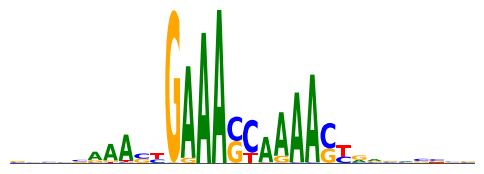

CAAACTGAAAC
AAAACTG


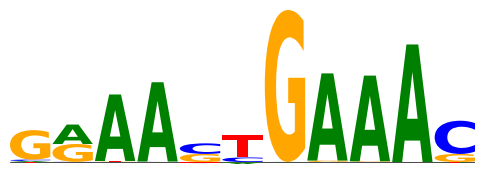

ARNT,ATF2,BACH1,BATF,BCL11A,BHLHE40,BMI1,CREB1,CREM,CUX1,EBF1,ELF1,ETV6,IKZF1,IKZF2,IRF1,IRF2,IRF4,JUND,MEF2A,MEF2B,MEF2C,MXI1,NFATC1,NFATC3,NR2F1,PAX5,PKNOX1,POU2F2,RELA,RELB,RUNX3,STAT1,TBX21,TCF12,TCF3,ZBED1,ZNF217,ZNF24,ZNF384,ZNF687


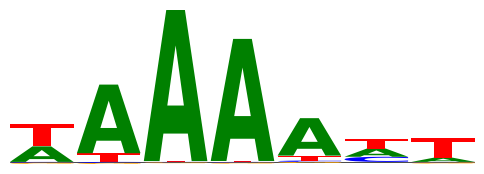

ARNT,ATF,BACH,BATF,BCL,BHLH,BMI,CREB,CREM,CUX,EBF,ELF,ETV,IKZF,IRF,JUN,MAX,MEF2A,MEF2B,MEF2C,NFAT,NR2F,PAX,PKNOX,POU,REL,RUNX,STAT,TBX,TCF,ZBED,ZNF
(1, 30, 8)


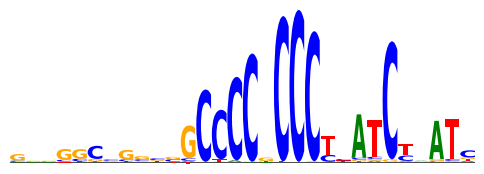

CCCCGCCC
ATCTA


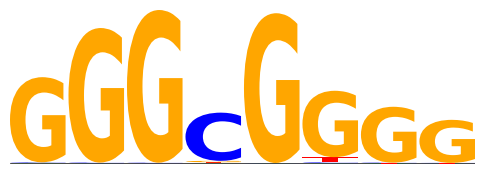

ARNT2,BCL3,BHLHE40,CEBPB,CLOCK,CREB1,ELF1,ETV6,FOS,FOXK1,GMEB1,HIVEP1,HOXA5,JUN,JUND,KLF1,KLF10,KLF12,KLF13,KLF16,KLF17,KLF4,KLF6,KLF7,KLF8,KLF9,MAFK,MAX,MAZ,MEIS2,MNT,MXI1,MYC,NRF1,PKNOX1,POU2F1,POU2F2,RREB1,RUNX3,SP1,SP2,SP3,SP4,SP5,SP7,SPDEF,SRF,STAT3,TBP,TEAD1,TFAP4,VEZF1,WT1,ZBTB17,ZEB2,ZFP90,ZNF143,ZNF221,ZNF274,ZNF341,ZNF384,ZNF407,ZNF414,ZNF430,ZNF444,ZNF547,ZNF561,ZNF605,ZNF784,ZNF788


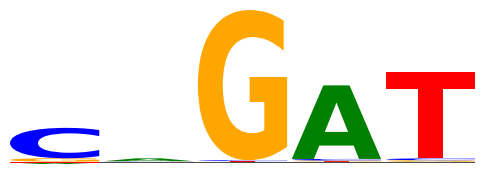

AP,ARNT,BCL,BHLH,CEBP,CLOCK,CREB,ELF,ETV,FOS,FOX,GMEB,HIVEP,HOX,JUN,KLF,MAF,MAX,MAZ,MEIS,MNT,MYC,NRF,PKNOX,POU,RREB,RUNX,SP,SRF,STAT,TBP,TEAD,VEZF,WT,ZBTB,ZEB,ZFP,ZNF
(1, 30, 8)


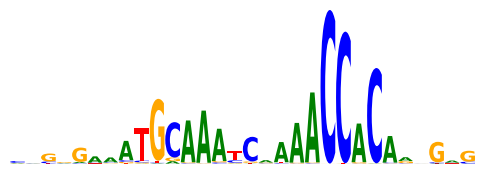

AACCACA
GGGAAATGCAAAT


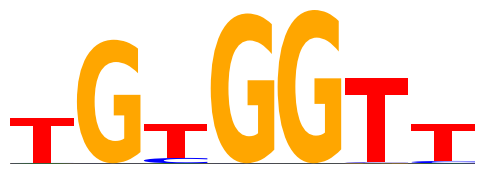

ARNT,ATF2,BATF,BCL11A,BHLHE40,BMI1,CBFB,CREB1,CREM,EBF1,ESRRA,ETV6,GATA3,HES1,IKZF1,IKZF2,IRF4,JUND,MAX,MEF2A,MEF2B,MEF2C,MYC,NFATC3,NFIC,NR2F1,PAX5,PBX3,POU2F2,RELA,RELB,RUNX1,RUNX3,SP1,TBX21,TCF12,TCF3,TCF7,TEAD1,TEAD4,ZBED1,ZNF217,ZNF24,ZNF687


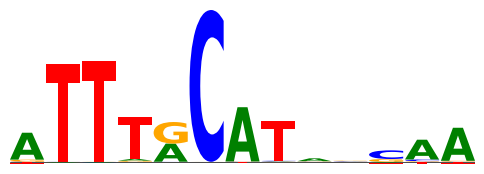

ARNT,ATF,BATF,BCL,BHLH,BMI,CBFB,CREB,CREM,EBF,ESRR,ETV,GATA,HES,IKZF,IRF,JUN,MAX,MEF2A,MEF2B,MEF2C,MYC,NFAT,NFI,NR2F,PAX,PBX,POU,REL,RUNX,SP,TBX,TCF,TEAD,ZBED,ZNF
(1, 30, 8)


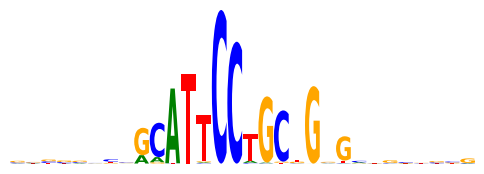

GCATTCC
TGCTGGGCGG


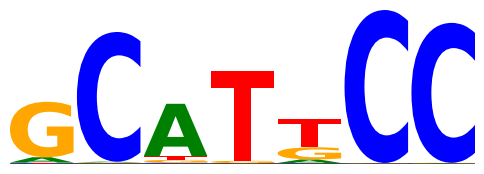

JUN,MAX,REST,TEAD4,ZNF462,ZNF8


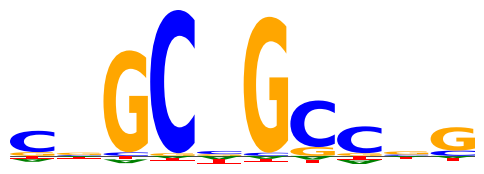

JUN,MAX,REST,TEAD,ZNF
(1, 30, 8)


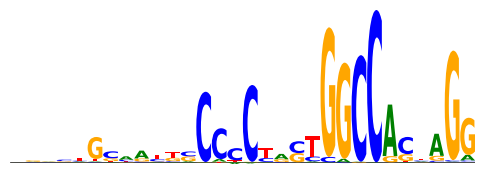

TGGCC
GG


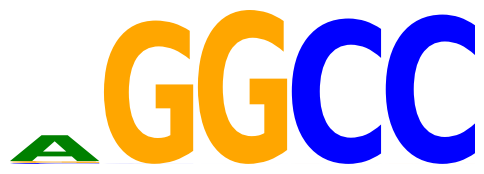

ZFY,ZNF687


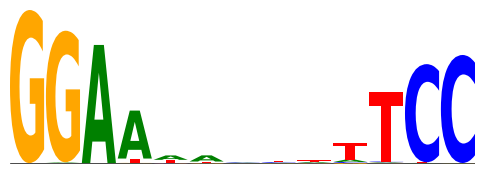

ZFY,ZNF
(1, 30, 8)


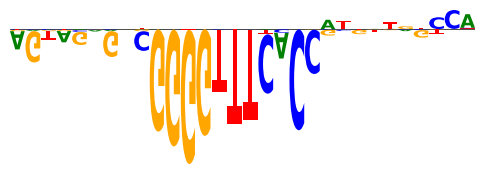

GGGGTTTCAC
CATGTTGGC


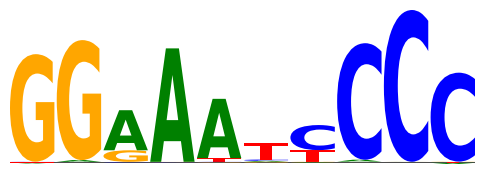

ARNT,ATF2,BATF,BCL11A,BCL3,BHLHE40,CBFB,CREB1,CREM,EBF1,EGR1,ETV6,FOS,HIVEP1,IKZF1,IKZF2,IRF4,MAZ,MEF2A,MEF2B,NFATC3,NR2F1,PAX5,POU2F2,RELA,RELB,RUNX3,TBX21,TCF12,ZBED1,ZNF687


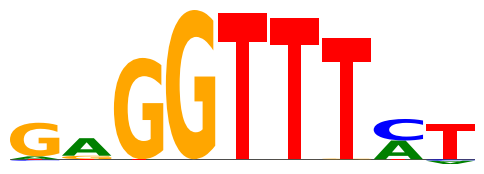

ARNT,ATF,BATF,BCL,BHLH,CBFB,CREB,CREM,EBF,EGR,ETV,FOS,HIVEP,IKZF,IRF,MAZ,MEF2A,MEF2B,NFAT,NR2F,PAX,POU,REL,RUNX,TBX,TCF,ZBED,ZNF
(1, 30, 8)


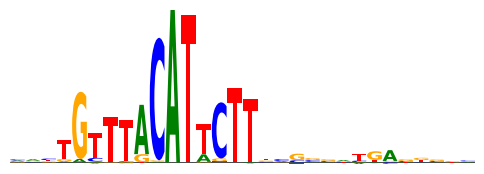

TTTACATTCTT
GAAAAAAAAA


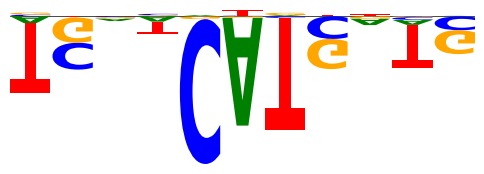

ZNF33B


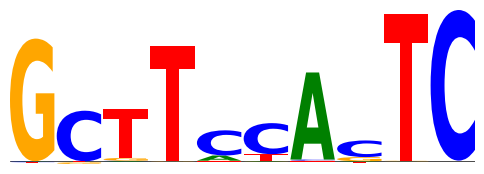

ZNF
(1, 30, 8)


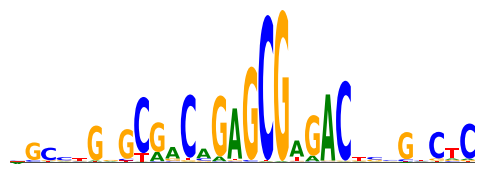

CGACAGAGCGAGAC
GTCTC


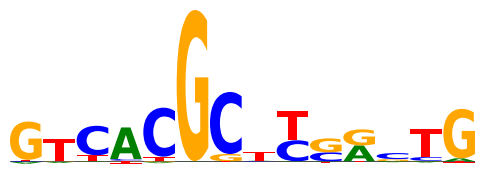

ESR1,NFIC,PAX5,PAX8


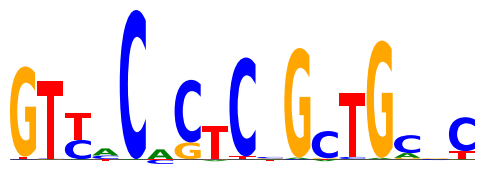

ESR,NFI,PAX
(1, 30, 8)


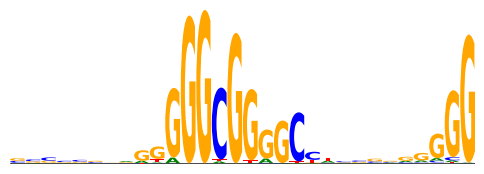

GGGCGGGG
GGGGG


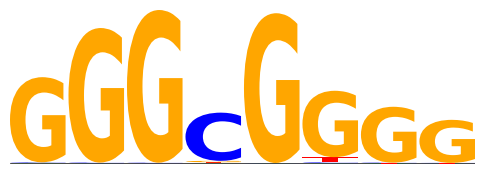

ARNT2,BCL3,BHLHE40,CEBPB,CLOCK,CREB1,ELF1,ETV6,FOS,FOXK1,GMEB1,HIVEP1,HOXA5,JUN,JUND,KLF1,KLF10,KLF12,KLF13,KLF16,KLF17,KLF4,KLF6,KLF7,KLF8,KLF9,MAFK,MAX,MAZ,MEIS2,MNT,MXI1,MYC,NRF1,PKNOX1,POU2F1,POU2F2,RREB1,RUNX3,SP1,SP2,SP3,SP4,SP5,SP7,SPDEF,SRF,STAT3,TBP,TEAD1,TFAP4,VEZF1,WT1,ZBTB17,ZEB2,ZFP90,ZNF143,ZNF221,ZNF274,ZNF341,ZNF384,ZNF407,ZNF414,ZNF430,ZNF444,ZNF547,ZNF561,ZNF605,ZNF784,ZNF788


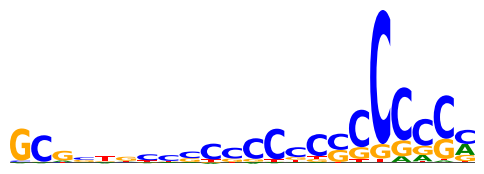

AP,ARNT,BCL,BHLH,CEBP,CLOCK,CREB,ELF,ETV,FOS,FOX,GMEB,HIVEP,HOX,JUN,KLF,MAF,MAX,MAZ,MEIS,MNT,MYC,NRF,PKNOX,POU,RREB,RUNX,SP,SRF,STAT,TBP,TEAD,VEZF,WT,ZBTB,ZEB,ZFP,ZNF
(1, 30, 8)


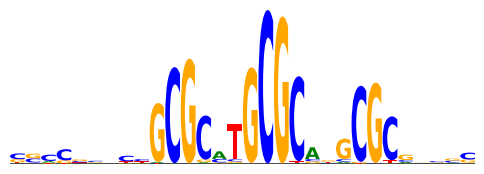

GCGCATGCGC
GCCCCAAAAAAAAAAAGGCGCGGCG


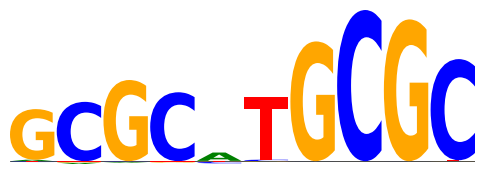

EGR1,MEIS2,NRF1,ZBTB2,ZNF639


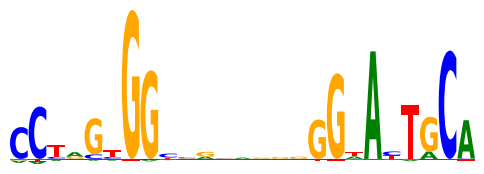

EGR,MEIS,NRF,ZBTB,ZNF
(1, 30, 8)


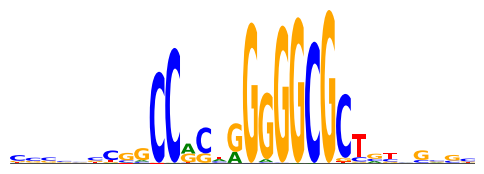

CCACTGGGGGCGC
C


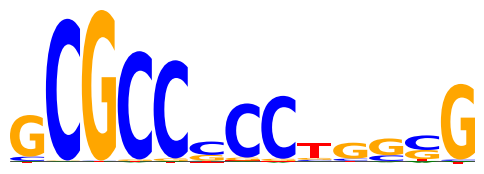

ADNP,ARNT2,ATF1,ATF3,CBFB,CREB1,CTCF,CTCFL,E2F8,EGR1,ELF1,ESRRA,GABPB1,HINFP,IRF2,JUN,KLF12,KLF17,MAX,MEIS1,MNT,MXI1,MYC,OVOL1,PAX5,PKNOX1,RELA,REST,SOX6,SP1,SP4,SP7,TEAD1,THAP11,USF1,YY1,ZBTB17,ZHX1,ZNF143,ZNF184,ZNF189,ZNF205,ZNF221,ZNF230,ZNF24,ZNF263,ZNF324,ZNF362,ZNF384,ZNF407,ZNF414,ZNF444,ZNF512B,ZNF526,ZNF548,ZNF556,ZNF580,ZNF607,ZNF614,ZNF639,ZNF697,ZNF740,ZNF772


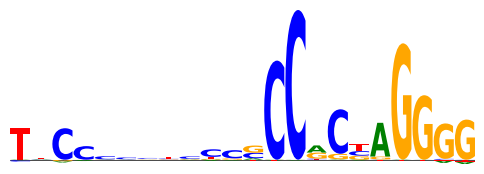

ADNP,ARNT,ATF,CBFB,CREB,CTCF,E2F,EGR,ELF,ESRR,GABP,HINFP,IRF,JUN,KLF,MAX,MEIS,MNT,MYC,OVOL,PAX,PKNOX,REL,REST,SOX,SP,TEAD,THAP,USF,YY,ZBTB,ZHX,ZNF
(1, 30, 8)


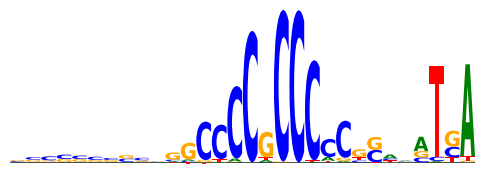

CCCCGCCC
CGGAAATGA


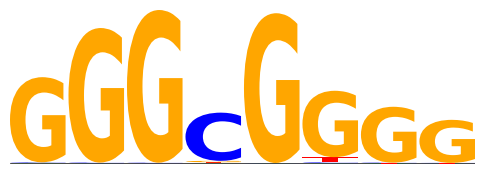

ARNT2,BCL3,BHLHE40,CEBPB,CLOCK,CREB1,ELF1,ETV6,FOS,FOXK1,GMEB1,HIVEP1,HOXA5,JUN,JUND,KLF1,KLF10,KLF12,KLF13,KLF16,KLF17,KLF4,KLF6,KLF7,KLF8,KLF9,MAFK,MAX,MAZ,MEIS2,MNT,MXI1,MYC,NRF1,PKNOX1,POU2F1,POU2F2,RREB1,RUNX3,SP1,SP2,SP3,SP4,SP5,SP7,SPDEF,SRF,STAT3,TBP,TEAD1,TFAP4,VEZF1,WT1,ZBTB17,ZEB2,ZFP90,ZNF143,ZNF221,ZNF274,ZNF341,ZNF384,ZNF407,ZNF414,ZNF430,ZNF444,ZNF547,ZNF561,ZNF605,ZNF784,ZNF788


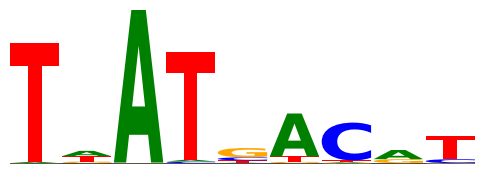

AP,ARNT,BCL,BHLH,CEBP,CLOCK,CREB,ELF,ETV,FOS,FOX,GMEB,HIVEP,HOX,JUN,KLF,MAF,MAX,MAZ,MEIS,MNT,MYC,NRF,PKNOX,POU,RREB,RUNX,SP,SRF,STAT,TBP,TEAD,VEZF,WT,ZBTB,ZEB,ZFP,ZNF
(1, 30, 8)


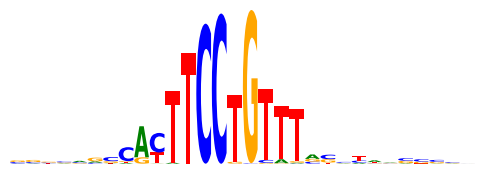

ACTTCCTGT
CCAAAAAAAAATTACCTAA


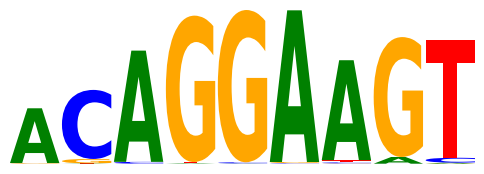

ZNF584,ZNF589,ZNF592


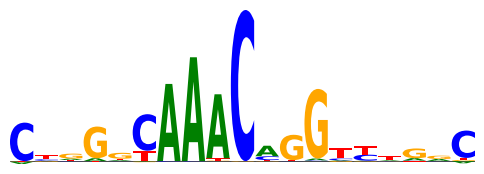

ZNF
(1, 30, 8)


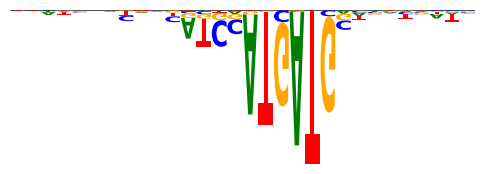

error
(1, 30, 8)


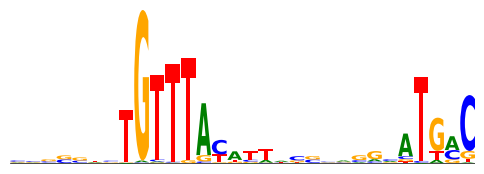

TGTTTACAT
CGCAGGCATGAC


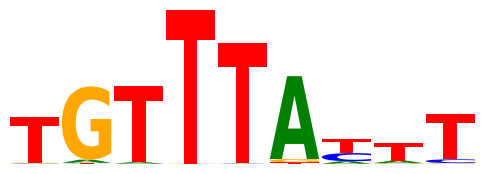

BCL6B,ESR1,GLI2,GLIS1,HIC2,HNF1A,IKZF3,INSM2,KLF16,KLF17,MLX,OVOL3,PRDM6,TFDP2,ZBTB40,ZEB2,ZNF221,ZNF488,ZNF557,ZNF766,ZNF816,ZNF843,ZNF878


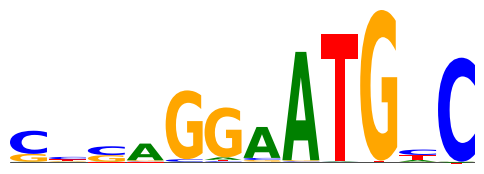

BCL,DP,ESR,GLI,GLIS,HIC,HNF1A,IKZF,INSM,KLF,MLX,OVOL,PRDM,ZBTB,ZEB,ZNF
(1, 30, 8)


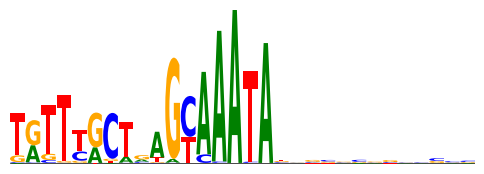

GCAAATATTG
TGTTTGCTGAAA


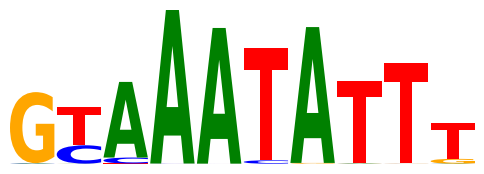

ARNT2,ARNTL,ATF2,ATF3,ATF4,BCL3,BCL6,BHLHE40,CBFB,CEBPA,CEBPB,CEBPD,CEBPG,CLOCK,CREB1,CREM,CUX1,E2F8,EGR1,ESR1,ETS1,ETV4,ETV5,FOS,FOSL1,FOSL2,FOXA1,FOXA2,FOXA3,FOXJ3,FOXK1,FOXO1,FOXP4,FOXQ1,GATA2,GATA3,GATA4,GFI1,HES2,HIC2,HIVEP1,HNF1A,HNF1B,HNF4A,HNF4G,HOXA5,HOXD1,IKZF5,IRF2,JUN,JUND,KLF16,KLF6,KLF9,MAX,MAZ,MEIS1,MEIS2,MGA,MLX,MNT,MXI1,MYPOP,NFIA,NFIC,NFIL3,NR2F1,NR2F2,NR2F6,NR3C1,NR5A1,NR5A2,ONECUT1,ONECUT2,OVOL1,PATZ1,PITX1,POU2F1,PPARG,PRDM1,REST,RREB1,RXRA,RXRB,SIX1,SIX4,SOX13,SOX5,SOX6,SP1,SP5,SPDEF,SRF,TBX3,TCF7,TCF7L2,TEAD1,TEAD4,TFAP4,TFE3,TGIF2,THAP11,THRA,YY1,ZBED4,ZBTB10,ZBTB25,ZBTB26,ZBTB33,ZBTB37,ZBTB43,ZBTB7B,ZEB1,ZFHX3,ZFP1,ZFP90,ZHX1,ZKSCAN8,ZMYM2,ZNF124,ZNF18,ZNF205,ZNF217,ZNF219,ZNF221,ZNF264,ZNF280D,ZNF281,ZNF292,ZNF317,ZNF331,ZNF350,ZNF362,ZNF384,ZNF414,ZNF430,ZNF431,ZNF48,ZNF501,ZNF503,ZNF511,ZNF543,ZNF556,ZNF580,ZNF607,ZNF608,ZNF609,ZNF614,ZNF639,ZNF644,ZNF652,ZNF670,ZNF691,ZNF710,ZNF746,ZNF747,ZNF772,ZNF788,ZNF792,ZNF816,ZNF865,ZNF878,ZSCAN25,ZSCAN9


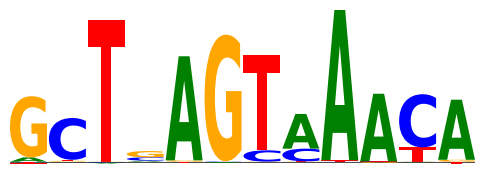

AP,ARNT,ATF,BCL,BHLH,CBFB,CEBP,CLOCK,CREB,CREM,CUX,E,E2F,EGR,ESR,ETS,ETV,FOS,FOX,GATA,GFI,HES,HIC,HIVEP,HNF1A,HNF1B,HNF4A,HNF4G,HOX,IKZF,IRF,JUN,KLF,MAX,MAZ,MEIS,MGA,MLX,MNT,MYPOP,NFI,NR2F,NR3C,NR5A,ONECUT,OVOL,PATZ,PITX,POU,PPAR,PRDM,REST,RREB,RXR,SIX,SOX,SP,SRF,TBX,TCF,TEAD,TGIF,THAP,THRA,YY,ZBED,ZBTB,ZBTB7B,ZEB,ZFHX,ZFP,ZHX,ZKSCAN,ZMYM,ZNF,ZSCAN
(1, 30, 8)


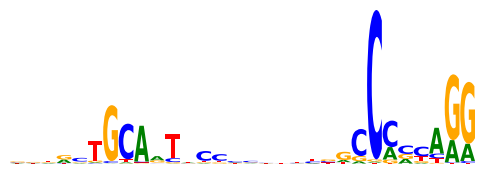

TTCCCCCCTTGGCCCCCAGG
TGCAAAAAAAAAAAAAAAAAAAAAA


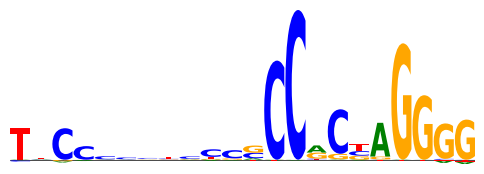

CTCF


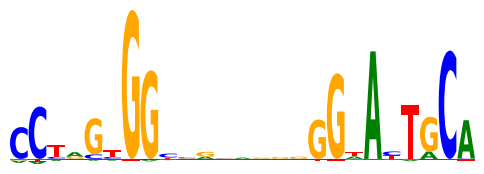

CTCF


In [14]:
from MotifCompendium.utils.motif import motif_8_to_4_signed
from MotifCompendium.utils.motif import trim_motif
from MotifCompendium.utils.plotting import plot_motif

#index=7
annotation_col="chipdb"
mc_sub.sort(by=f"{annotation_col}_score1", ascending=False, inplace=True)
# chiptf1 = "-"+mc_sub.metadata["chiptf_name0"]
# chiptf2 = "-"+mc_sub.metadata["chiptf_name1"]
chiptf1 = mc_sub.metadata["chipdb_name0"]
chiptf2 = mc_sub.metadata["chipdb_name1"]
id_to_nucleotide = {0: 'A', 1: 'C', 2: 'G', 3: 'T'}

motif1_strings = []
motif2_strings = []
motif1_locs = []
motif2_locs = []

refmotif1 = []
refmotif2 = []

debug=True
#print(mc_sub.metadata.shape[0])
for index in range(mc_sub.metadata.shape[0]):
#for index in range(0,3):

    #print(index)
    #print(chiptf1[index])
    

    
    my_motifs=mc_sub.motifs[index][None,:,:]
    my_motifs_orig=np.array(my_motifs).copy()
    reference_motifs1=mcref.motifs[mcref.metadata["label"]==chiptf1[index]]
    reference_motifs2=mcref.motifs[mcref.metadata["label"]==chiptf2[index]]
    #print(reference_motifs1.shape)
    # refmotif1.append(reference_motifs1)
    # refmotif2.append(reference_motifs2)
    
    my_motifs = motif_8_to_4_signed(my_motifs[0])
    reference_motifs1 = trim_motif(motif_8_to_4_signed(reference_motifs1[0]), 1/30)
    reference_motifs2 = trim_motif(motif_8_to_4_signed(reference_motifs2[0]), 1/30)
    if debug:
        print(my_motifs_orig.shape)
        plot_motif(my_motifs)
        # plot_motif(reference_motifs1)
        # print(chiptf1[index].split("add")[0])
        # plot_motif(reference_motifs2)
        # print(chiptf1[index].split("add")[1])
        

    if (reference_motifs1.shape[0] > my_motifs.shape[0]) or (reference_motifs2.shape[0] > my_motifs.shape[0]):
        print("error")
        motif1_strings.append("NA")
        motif1_locs.append(str(0)+","+str(0))
        motif2_strings.append("NA")
        motif2_locs.append(str(0)+","+str(0))

        continue

    num_rows_submatrix, num_columns = reference_motifs1.shape
    num_rows_submatrix2, num_columns2 = reference_motifs2.shape

    #print(num_rows_submatrix2, my_motifs.shape)
    #sub_motif1, best_position = find_max_similarity_position(debug, my_motifs, reference_motifs1)
    # if debug:
    #     plot_motif(sub_motif1)
    # sub_motif1_ids = np.argmax(sub_motif1, axis=1)
    # # Convert the numeric IDs to nucleotide characters
    # sub_motif1_chars = [id_to_nucleotide[id_] for id_ in sub_motif1_ids]
    # # Join the characters into a string
    # sub_motif1_string = ''.join(sub_motif1_chars)
    # if debug:
    #     print(sub_motif1_string)
    #     print(best_position, best_position+num_rows_submatrix)
    # motif1_strings.append(sub_motif1_string)
    # motif1_locs.append(str(best_position)+","+str(best_position+num_rows_submatrix))
    
    # my_motifs[best_position:best_position+num_rows_submatrix]=0
 
    sub_motif1, best_position, end_position = find_max_similarity_position_new(debug, my_motifs, reference_motifs1)
    sub_motif1_ids = np.argmax(sub_motif1, axis=1)
    sub_motif1_chars = [id_to_nucleotide[id_] for id_ in sub_motif1_ids]
    sub_motif1_string = ''.join(sub_motif1_chars)
    motif1_strings.append(sub_motif1_string)
    motif1_locs.append(str(best_position)+","+str(end_position))
    # if debug:
    #     plot_motif(sub_motif1)
    #     print(sub_motif1_string)
    #     print(best_position, best_position+num_rows_submatrix)

    
    my_motifs[best_position:end_position]=0
    sub_motif2, best_position2, end_position2 = find_max_similarity_position_new(debug, my_motifs, reference_motifs2, [best_position,best_position+num_rows_submatrix])
    sub_motif2_ids = np.argmax(sub_motif2, axis=1)
    sub_motif2_chars = [id_to_nucleotide[id_] for id_ in sub_motif2_ids]
    sub_motif2_string = ''.join(sub_motif2_chars)
    motif2_strings.append(sub_motif2_string)
    motif2_locs.append(str(best_position2)+","+str(end_position2))
    # if debug:
    #     plot_motif(sub_motif2)
    #     print(sub_motif2_string)
    #     print(best_position2, end_position2)

    if debug:
        print(sub_motif1_string)
        print(sub_motif2_string)
        plot_motif(reference_motifs1)
        print(chiptf1[index].split("add")[0])
        plot_motif(reference_motifs2)
        print(chiptf1[index].split("add")[1])
        
        
   # sub_motif2, best_position2 = find_max_similarity_position(debug, my_motifs, reference_motifs2, [best_position,best_position+num_rows_submatrix])
   #  if debug:
   #      plot_motif(sub_motif2)
   #  sub_motif2_ids = np.argmax(sub_motif2, axis=1)
   #  # Convert the numeric IDs to nucleotide characters
   #  sub_motif2_chars = [id_to_nucleotide[id_] for id_ in sub_motif2_ids]
   #  # Join the characters into a string
   #  sub_motif2_string = ''.join(sub_motif2_chars)
   #  if debug:
   #      print(sub_motif2_string)
   #      print(best_position2, best_position2+num_rows_submatrix2)
   #  motif2_strings.append(sub_motif2_string)
   #  motif2_locs.append(str(best_position2)+","+str(best_position2+num_rows_submatrix2))
    #break

In [15]:
#from MotifCompendium.utils.plotting import plot_motif

# refmotif1=np.array(refmotif1)
# refmotif2=np.array(refmotif2)


In [16]:
refmotif1.shape

AttributeError: 'list' object has no attribute 'shape'

In [17]:
#reference_motifs1.shape
#mc_sub_pos = mc_sub[mc_sub["posneg"]=="pos"]

In [18]:
#sum(mc_sub_pos['chiptf_score1']>0.6)

In [19]:
#sub_motif2

In [20]:
mc_sub["motif1_strings"] = motif1_strings
mc_sub["motif2_strings"] = motif2_strings
mc_sub["motif1_locs"] = motif1_locs
mc_sub["motif2_locs"] = motif2_locs


In [21]:
#mc_sub.columns()

In [22]:
#mc_sub.summary_table_html("tutorials/chrombpnet_outputs/composites_summary_table.html")


In [23]:
#mc_sub[mc_sub["posneg"]=="pos"].summary_table_html("tutorials/chrombpnet_outputs/pos_composites_summary_table_refdb.html")


In [24]:
#mc_sub[mc_sub["posneg"]=="neg"].summary_table_html("tutorials/chrombpnet_outputs/neg_composites_summary_table.html")


In [25]:
#mc_sub_pos = mc_sub[mc_sub["posneg"]=="pos"]
mc_sub_pos = mc_sub

In [26]:
mc_sub_pos.columns()

['name_x',
 'num_seqlets',
 'model',
 'posneg',
 'avg_contrib',
 'avg_dist_from_summit',
 'cluster',
 'selex_score0',
 'selex_name0',
 'chipdb_score0',
 'chipdb_name0',
 'chipdb_score1',
 'chipdb_name1',
 'motif_entropy',
 'weighted_base_entropy',
 'weighted_position_entropy',
 'posbase_entropy_score',
 'copair_entropy_score',
 'copair_composition',
 'dinuc_entropy_score',
 'dinuc_composition',
 'dinuc_score',
 'posneg_inverted',
 'truncated',
 'flag_remove',
 'name_y',
 'label',
 'motif1_strings',
 'motif2_strings',
 'motif1_locs',
 'motif2_locs']

In [27]:
# mc_sub_pos.metadata = mc_sub_pos.metadata[['name',
#  'motif1_strings',
#  'motif2_strings',
#  'chiptf_name0',   
#  'chiptf_name1',
#  'chiptf_score0',
#  'chiptf_score1',
#  'selex_score0',
#  'selex_name0',
#  'motif1_locs',
#  'motif2_locs',                                           
#  'posneg',
#  'num_seqlets',
#  'model',
#  'avg_contrib',
#  'avg_dist_from_summit',
#  'cluster']
# ]

In [28]:
# mc_sub_pos = mc_sub[mc_sub["posneg"]=="pos"]
# currcu=['name',
#  'num_seqlets',
#  'model',
#  'refdb_logo0',
#  'motif1_strings',
# 'refdb_logo1',
#  'motif2_strings',
#  'refdb_score0',
#  'refdb_name0',
#  'refdb_score1',
#  'refdb_name1',
#  'chiptf_score0',
#  'chiptf_name0',
#  'chiptf_score1',
#  'chiptf_name1',
#  'motif1_locs',
#  'motif2_locs',                                           
#  'posneg',
#  'avg_contrib',
#  'avg_dist_from_summit',
#  'cluster'
# ]

# mc_sub_pos.summary_table_html("tutorials/chrombpnet_outputs/pos_composites_summary_table_refdb.html", columns=currcu)

In [29]:
#mc_sub_pos

In [30]:
#mc_sub_pos.delete_images(["logo (fwd)", "logo (rev)"])

mc_sub_pos.add_logos(mc_sub_pos.get_standard_motif_stack(), "chipdb_logo0", trim=True)
import MotifCompendium.utils.motif as utils_motif
mc_sub_pos.add_logos(utils_motif.reverse_complement(mc_sub_pos.get_standard_motif_stack()), "chipdb_logo0", trim=False)

currcu=[
 'motif1_strings',
 'motif2_strings',
 'chipdb_logo0',
 'chipdb_logo1',
 'chipdb_score0',
 'chipdb_name0',
 'chipdb_score1',
 'chipdb_name1',
 'selex_logo0',
 'selex_score0',
 'selex_name0',
 'motif1_locs',
 'motif2_locs',                                           
 'posneg',
 'avg_contrib',
 'avg_dist_from_summit',
 'cluster',
 'name_x',
 'num_seqlets',
 'model'
]

mc_sub_pos.summary_table_html("composites_summary_table.html", columns=currcu)
mc_sub_pos.metadata.to_csv("composites_summary_table.tsv", sep=",", index=False)

In [31]:
mc_sub_pos

,name_x,num_seqlets,model,posneg,avg_contrib,avg_dist_from_summit,cluster,selex_score0,selex_name0,chipdb_score0,...,dinuc_score,posneg_inverted,truncated,flag_remove,name_y,label,motif1_strings,motif2_strings,motif1_locs,motif2_locs
0,HEPG2_profile-neg.pattern_4,612,HEPG2_profile,neg,-0.016526,75.617647,182,0.632053,CAPSLX.HMX3::RUNX2.0,0.807137,...,0.142586,False,False,False,cpm_leiden_0.88-rec-force0.92#60,"BCL11A,CTCF,MLXIP,PRDM6,RARB,TP53,ZFP37,ZNF337...",CCCCA,AAATTTA,"14,19","19,26"
1,GM12878_profile-neg.pattern_35,345,GM12878_profile,neg,-0.017562,78.315942,348,0.610337,CAPSLX.KLF13::FLI1.0,0.831671,...,0.184913,False,False,False,cpm_leiden_0.88-rec-force0.92#1322,MEF2BaddMEF2BaddZNF354CaddJASP.MA0098.1.ETS1,GGA,TCC,"9,12","21,24"
2,HEPG2_counts-pos.pattern_26,698,HEPG2_counts,pos,0.399636,62.971347,48,0.742343,CAPSLX.SOX14::TBX4.0,0.839244,...,0.174850,False,False,False,cpm_leiden_0.88-rec-force0.92#134,"SOX13,SOX5,SOX6addSOXaddSOX10,SOX11,SOX12,SOX1...",AACAAAGG,CCTTTGTT,"6,14","15,23"
3,H1ESC_counts-pos.pattern_23,206,H1ESC_counts,pos,0.440568,51.223301,69,0.777812,CAPSLX.OTX2::SOX11.0,0.806723,...,0.171708,False,False,False,cpm_leiden_0.88-rec-force0.92#29,"BHLHE40,BNC2,CEBPB,CREB5,ETS1,FOS,FOSL2,FOXA1,...",AACAAAGG,AATGCCT,"15,23","23,30"
4,HEPG2_profile-pos.pattern_33,792,HEPG2_profile,pos,0.032032,67.372475,48,0.727833,CAPSLX.SOX14::TBX4.0,0.840714,...,0.194097,False,False,False,cpm_leiden_0.88-rec-force0.92#134,"SOX13,SOX5,SOX6addSOXaddSOX10,SOX11,SOX12,SOX1...",CCTTTGTT,AACAAAGG,"16,24","7,15"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,IMR90_profile-pos.pattern_44,239,IMR90_profile,pos,0.049158,65.853556,286,0.856332,CAPSLX.ELF1::FOXO1.1,0.862591,...,0.166552,False,False,False,cpm_leiden_0.88-rec-force0.92#808,ESR1addESRaddGRHL2addHOCO.GRHL2.H13CORE.0.P.B,ACTTCCTGT,CCAAAAAAAAATTACCTAA,"8,17","6,25"
62,K562_counts-neg.pattern_7,102,K562_counts,neg,-0.174849,80.196078,556,0.721528,CAPSLX.HOXA4::CREM.0,0.821275,...,0.320722,False,False,False,cpm_leiden_0.88-rec-force0.92#525,"ZNF865addZNFaddFOXL1,SALL3addHOCO.SIX6.H13CORE...",NA,NA,"0,0","0,0"
63,IMR90_profile-pos.pattern_56,158,IMR90_profile,pos,0.074583,63.664557,293,0.726055,CAPSLX.FOXM1.0,0.811494,...,0.227028,False,False,False,cpm_leiden_0.88-rec-force0.92#993,BNC2addBNCaddYY1addJASP.MA0808.1.TEAD3,TGTTTACAT,CGCAGGCATGAC,"7,16","18,30"
64,HEPG2_profile-pos.pattern_58,107,HEPG2_profile,pos,0.045362,75.401869,107,0.717597,CAPSLX.FOXB1::TEAD4.0,0.823515,...,0.178739,False,False,False,cpm_leiden_0.88-rec-force0.92#1140,"ZNF24addZNFaddBACH1,NF2L1,NF2L2,NFE2,NFE2L2add...",GCAAATATTG,TGTTTGCTGAAA,"10,20","0,12"


In [32]:
# for index in range(mc_sub_pos.motifs.shape[0]):
#     print(mc_sub_pos.motifs[index].shape)
#     plot_motif(motif_8_to_4_signed(mc_sub_pos.motifs[index]))

In [33]:
#mc_sub_pos.metadata[currcu]

In [34]:
mc_sub_pos

,name_x,num_seqlets,model,posneg,avg_contrib,avg_dist_from_summit,cluster,selex_score0,selex_name0,chipdb_score0,...,dinuc_score,posneg_inverted,truncated,flag_remove,name_y,label,motif1_strings,motif2_strings,motif1_locs,motif2_locs
0,HEPG2_profile-neg.pattern_4,612,HEPG2_profile,neg,-0.016526,75.617647,182,0.632053,CAPSLX.HMX3::RUNX2.0,0.807137,...,0.142586,False,False,False,cpm_leiden_0.88-rec-force0.92#60,"BCL11A,CTCF,MLXIP,PRDM6,RARB,TP53,ZFP37,ZNF337...",CCCCA,AAATTTA,"14,19","19,26"
1,GM12878_profile-neg.pattern_35,345,GM12878_profile,neg,-0.017562,78.315942,348,0.610337,CAPSLX.KLF13::FLI1.0,0.831671,...,0.184913,False,False,False,cpm_leiden_0.88-rec-force0.92#1322,MEF2BaddMEF2BaddZNF354CaddJASP.MA0098.1.ETS1,GGA,TCC,"9,12","21,24"
2,HEPG2_counts-pos.pattern_26,698,HEPG2_counts,pos,0.399636,62.971347,48,0.742343,CAPSLX.SOX14::TBX4.0,0.839244,...,0.174850,False,False,False,cpm_leiden_0.88-rec-force0.92#134,"SOX13,SOX5,SOX6addSOXaddSOX10,SOX11,SOX12,SOX1...",AACAAAGG,CCTTTGTT,"6,14","15,23"
3,H1ESC_counts-pos.pattern_23,206,H1ESC_counts,pos,0.440568,51.223301,69,0.777812,CAPSLX.OTX2::SOX11.0,0.806723,...,0.171708,False,False,False,cpm_leiden_0.88-rec-force0.92#29,"BHLHE40,BNC2,CEBPB,CREB5,ETS1,FOS,FOSL2,FOXA1,...",AACAAAGG,AATGCCT,"15,23","23,30"
4,HEPG2_profile-pos.pattern_33,792,HEPG2_profile,pos,0.032032,67.372475,48,0.727833,CAPSLX.SOX14::TBX4.0,0.840714,...,0.194097,False,False,False,cpm_leiden_0.88-rec-force0.92#134,"SOX13,SOX5,SOX6addSOXaddSOX10,SOX11,SOX12,SOX1...",CCTTTGTT,AACAAAGG,"16,24","7,15"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,IMR90_profile-pos.pattern_44,239,IMR90_profile,pos,0.049158,65.853556,286,0.856332,CAPSLX.ELF1::FOXO1.1,0.862591,...,0.166552,False,False,False,cpm_leiden_0.88-rec-force0.92#808,ESR1addESRaddGRHL2addHOCO.GRHL2.H13CORE.0.P.B,ACTTCCTGT,CCAAAAAAAAATTACCTAA,"8,17","6,25"
62,K562_counts-neg.pattern_7,102,K562_counts,neg,-0.174849,80.196078,556,0.721528,CAPSLX.HOXA4::CREM.0,0.821275,...,0.320722,False,False,False,cpm_leiden_0.88-rec-force0.92#525,"ZNF865addZNFaddFOXL1,SALL3addHOCO.SIX6.H13CORE...",NA,NA,"0,0","0,0"
63,IMR90_profile-pos.pattern_56,158,IMR90_profile,pos,0.074583,63.664557,293,0.726055,CAPSLX.FOXM1.0,0.811494,...,0.227028,False,False,False,cpm_leiden_0.88-rec-force0.92#993,BNC2addBNCaddYY1addJASP.MA0808.1.TEAD3,TGTTTACAT,CGCAGGCATGAC,"7,16","18,30"
64,HEPG2_profile-pos.pattern_58,107,HEPG2_profile,pos,0.045362,75.401869,107,0.717597,CAPSLX.FOXB1::TEAD4.0,0.823515,...,0.178739,False,False,False,cpm_leiden_0.88-rec-force0.92#1140,"ZNF24addZNFaddBACH1,NF2L1,NF2L2,NFE2,NFE2L2add...",GCAAATATTG,TGTTTGCTGAAA,"10,20","0,12"


In [114]:
#mc_sub_pos.get_standard_motif_stack().shape

(66, 30, 4)

In [ ]:
#refmotif1

Matched database motif (first): CTCF,ZNF615addCTCF,ZNFaddZN384,ZNF362,ZNF384addJASP.MA1125.1.ZNF384


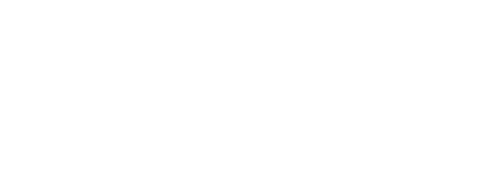

'iVBORw0KGgoAAAANSUhEUgAAAeQAAACuCAYAAADnGn5HAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjUsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvWftoOwAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAtRJREFUeJzt1TEBACAMwDDAv+chYz0SBf16Z2YOALDqbQcAAIYMAAmGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgwAAYYMAAGGDAABhgw

In [125]:
from IPython.display import Image, display
import base64
import gdown


annotation_col="chipdb"
match_fwd = mc_sub_pos.get_images(f"{annotation_col}_logo1")
image_bytes = base64.b64decode(match_fwd[0])
print(f"Matched database motif (first): {mc_sub_pos.metadata[f'{annotation_col}_name0'][1]}")
display(Image(data=image_bytes, format='png'))